# 국민여행조사 × 지방재정 세출현황 통합 분석 (트랙1·트랙2)

**작성**: 2조 데이터 분석 프로젝트 통합본 | **기준 문서**: `국민여행조사_트랙별_분석방법론_정리_개정판.pdf` (5절 신규 추가, 최종 개정판)

## 이 노트북의 목적
팀원 4인(승희·지수·진경·은영)이 각자 진행한 탐색적 분석 중, **팀이 최종 확정한 방법론 개정판 PDF에 명시된 절차만**을 골라
**실제 데이터(원본 CSV 2종)로 처음부터 다시 재현**하여 하나의 통합 파이프라인으로 만든 것이다. 방법론 문서에 없는 분석
(예: 고정효과 회귀, 순열검정, 부트스트랩, 세부사업명 110건 추가 제외 등 팀원 개인 노트북에만 있던 확장 시도)은
포함하지 않았다. 문서 내 수치(예: "서울 289배", "울산 울주군 사례" 등)는 방법론 설명을 위한 예시이므로,
아래 모든 수치는 **이 노트북을 실제로 실행해서 얻은 최종 정확한 값**이다.

## 사용 원본 데이터 (2개 파일만 사용, 팀 전처리 완료본)
| 파일 | 단위 | 크기 | 핵심 컬럼 |
|---|---|---|---|
| `team_combined_2023_2024_2025_processed.csv` | 응답자 1행 | 156,050행 × 101열 | `wt_dom`(가중치), `year`, `trip_cnt_{17개지역}`/`trip_exp_{17개지역}`(1~6차 전체 사전집계, 트랙1용), `trip1_start_month`, `trip1_dest_sido`/`trip1_dest_sigungu_nm`(1차 방문지, 이미 디코딩됨), `trip1_case`(여행목적), `trip1_cost`/`trip1_cost_per_person`/`trip1_num`(트랙2용) |
| `team_regional_expenditure_2023_2024_2025_processed.csv` | 세부사업 1행 | 48,617행 × 19열 | `region`/`municipality`(시도/시군구, `본청`=광역 단위), `subsector`(관광/문화재/문화및관광일반), `budget_total`/`budget_national`/`budget_sido`/`budget_sigungu`/`budget_other`/`expenditure`/`balance`/`local_own_revenue`(=시도비+시군구비), `year` |

## 트랙 구조 (방법론 0절)
- **트랙1(연간 상관관계)**: 시/도×연도(n=51) 단위. 방문↔지출↔지자체예산 상관관계 검증(가설1·가설2). 1~6차 전체 회차 사전집계 컬럼 사용.
- **트랙2(월별 실시간 조회)**: 시/도×월(3개년 통합, n=204) 단위. 챗봇/시각화용 1인 평균 지출·혼잡도 제공. 1회차(trip1_*) 데이터만 사용.
- 두 트랙은 **완전히 독립적으로 계산**하며 상호 재합산·교차검증하지 않는다.
- **여행목적(CASE) 처리 [개정 확정]**: 두 트랙 모두 국민여행조사 공식 "관광전체" 정의 — `trip1_case`가 1(관광/휴양)·2(친지방문+관광)·4(출장+관광)인 경우만 포함, 3(단순 방문)·5(단순 출장)은 제외. 트랙1의 `trip_cnt_*`/`trip_exp_*`는 원본 컬럼명이 이미 "관광전체_{지역}"이므로 이 정의로 사전집계되어 있어 별도 필터가 필요 없고, 트랙2와 1-5절의 SPOT 기반 재현은 원본 `trip1_case`에 이 필터를 직접 적용한다.

In [1]:
from pathlib import Path
import platform
import pandas as pd
import numpy as np
import matplotlib
# Jupyter(노트북) 환경이면 인라인 표시가 되도록 %matplotlib inline 사용,
# 화면 없는 headless 환경(터미널 스크립트 실행 등)이면 Agg로 안전하게 대체
try:
    ip = get_ipython()
except NameError:
    ip = None
if ip is not None:
    ip.run_line_magic('matplotlib', 'inline')
else:
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# ── 프로젝트 루트 탐색 ─────────────────────────────────────────────
def find_project_root(start: Path) -> Path:
    start = start.resolve()
    candidates = [start, *start.parents]
    for p in candidates:
        combined = p / "data" / "processed" / "team_combined_2023_2024_2025_processed.csv"
        regional = p / "data" / "processed" / "team_regional_expenditure_2023_2024_2025_processed.csv"
        if combined.exists() and regional.exists():
            return p
    raise FileNotFoundError(
        "프로젝트 루트를 찾지 못했습니다. out-traveler 폴더 안에서 이 노트북을 실행하고, "
        "data/processed의 두 전처리 CSV가 존재하는지 확인하세요."
    )

PROJECT_ROOT = find_project_root(Path.cwd())
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "team"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

COMBINED_PATH = PROCESSED_DIR / "team_combined_2023_2024_2025_processed.csv"
REGIONAL_PATH = PROCESSED_DIR / "team_regional_expenditure_2023_2024_2025_processed.csv"

# ── 한글 폰트 설정 (Windows 우선, 다른 OS도 대응) ─────────────────
def set_korean_font():
    system = platform.system()
    font_candidates = []

    if system == "Windows":
        font_candidates = [
            Path(r"C:\\Windows\\Fonts\\malgun.ttf"),
            Path(r"C:\\Windows\\Fonts\\malgunbd.ttf"),
        ]
    elif system == "Darwin":
        font_candidates = [
            Path("/System/Library/Fonts/AppleSDGothicNeo.ttc"),
            Path("/Library/Fonts/AppleGothic.ttf"),
        ]
    else:
        font_candidates = [
            Path("/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"),
            Path("/usr/share/fonts/truetype/nanum/NanumGothic.ttf"),
        ]

    for font_path in font_candidates:
        if font_path.exists():
            fm.fontManager.addfont(str(font_path))
            font_name = fm.FontProperties(fname=str(font_path)).get_name()
            plt.rcParams["font.family"] = font_name
            return font_name

    # 경로 기반 탐색에 실패하면 설치된 폰트명에서 재탐색
    installed = {f.name for f in fm.fontManager.ttflist}
    for name in ["Malgun Gothic", "Apple SD Gothic Neo", "NanumGothic", "Noto Sans CJK KR", "Noto Sans CJK JP"]:
        if name in installed:
            plt.rcParams["font.family"] = name
            return name

    return None

KOREAN_FONT = set_korean_font()
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# ── 데이터 로드 ────────────────────────────────────────────────────
combined = pd.read_csv(COMBINED_PATH, encoding="utf-8-sig")
reg = pd.read_csv(REGIONAL_PATH, encoding="utf-8-sig")

print("PROJECT_ROOT :", PROJECT_ROOT)
print("OUTPUT_DIR   :", OUTPUT_DIR)
print("한글 폰트     :", KOREAN_FONT if KOREAN_FONT else "자동 설정 실패 - 시스템 폰트 확인 필요")
print("combined (국민여행조사 통합):", combined.shape, "(156,050 x 101 이어야 함)")
print("reg (지방재정 세출현황)     :", reg.shape, "(48,617 x 19 이어야 함)")
print()
print("combined 연도 분포:", dict(combined["year"].value_counts().sort_index()))
print("reg 연도 분포     :", dict(reg["year"].value_counts().sort_index()))
print("reg subsector 종류:", list(reg["subsector"].unique()))


PROJECT_ROOT : C:\Users\duath\Documents\Github\out-traveler
OUTPUT_DIR   : C:\Users\duath\Documents\Github\out-traveler\outputs\team
한글 폰트     : Malgun Gothic
combined (국민여행조사 통합): (156050, 101) (156,050 x 101 이어야 함)
reg (지방재정 세출현황)     : (48617, 19) (48,617 x 19 이어야 함)

combined 연도 분포: {2023: np.int64(52111), 2024: np.int64(51754), 2025: np.int64(52185)}
reg 연도 분포     : {2023: np.int64(16191), 2024: np.int64(16066), 2025: np.int64(16360)}
reg subsector 종류: ['관광', '문화및관광일반', '문화재']


In [2]:
# ---- pure-numpy replacement for scipy.pearsonr / spearmanr (scipy is not in the team uv venv) ----
# Verified against scipy.stats output to match to >=6 decimal places, ties included.
import math

def _betacf(a, b, x):
    MAXIT, EPS, FPMIN = 200, 3e-16, 1e-300
    qab, qap, qam = a + b, a + 1, a - 1
    c = 1.0
    d = 1.0 - qab * x / qap
    if abs(d) < FPMIN: d = FPMIN
    d = 1.0 / d
    h = d
    for m in range(1, MAXIT + 1):
        m2 = 2 * m
        aa = m * (b - m) * x / ((qam + m2) * (a + m2))
        d = 1.0 + aa * d
        if abs(d) < FPMIN: d = FPMIN
        c = 1.0 + aa / c
        if abs(c) < FPMIN: c = FPMIN
        d = 1.0 / d
        h *= d * c
        aa = -(a + m) * (qab + m) * x / ((a + m2) * (qap + m2))
        d = 1.0 + aa * d
        if abs(d) < FPMIN: d = FPMIN
        c = 1.0 + aa / c
        if abs(c) < FPMIN: c = FPMIN
        d = 1.0 / d
        de = d * c
        h *= de
        if abs(de - 1.0) < EPS:
            break
    return h

def _betai(a, b, x):
    if x <= 0: return 0.0
    if x >= 1: return 1.0
    bt = math.exp(math.lgamma(a + b) - math.lgamma(a) - math.lgamma(b) + a * math.log(x) + b * math.log(1 - x))
    if x < (a + 1) / (a + b + 2):
        return bt * _betacf(a, b, x) / a
    return 1.0 - bt * _betacf(b, a, 1 - x) / b

def _t_sf(t, df):
    x = df / (df + t * t)
    return 0.5 * _betai(df / 2.0, 0.5, x)

def pearsonr(x, y):
    """Drop-in replacement for scipy.pearsonr(x, y) -> (r, p_two_tailed)."""
    x = np.asarray(x, dtype=float); y = np.asarray(y, dtype=float)
    n = len(x)
    xm, ym = x - x.mean(), y - y.mean()
    r = float(np.sum(xm * ym) / np.sqrt(np.sum(xm ** 2) * np.sum(ym ** 2)))
    r = max(min(r, 1.0), -1.0)
    df = n - 2
    if df <= 0 or abs(r) >= 1:
        return r, 0.0
    t = r * math.sqrt(df / (1 - r ** 2))
    return r, 2 * _t_sf(abs(t), df)

def _rankdata(a):
    """Average-rank tie handling, matching scipy.stats.rankdata(method='average')."""
    a = np.asarray(a, dtype=float)
    sorter = np.argsort(a, kind='mergesort')
    ranks = np.empty(len(a), dtype=float)
    ranks[sorter] = np.arange(1, len(a) + 1)
    _, inverse, counts = np.unique(a, return_inverse=True, return_counts=True)
    sums = np.zeros(len(counts))
    np.add.at(sums, inverse, ranks)
    return (sums / counts)[inverse]

def spearmanr(x, y):
    """Drop-in replacement for scipy.spearmanr(x, y) -> (rho, p_two_tailed)."""
    return pearsonr(_rankdata(x), _rankdata(y))

In [3]:
# ---- 그래프 라벨 helper: 영문 대신 한글 라벨을 그대로 사용 ----
REGION_KO2EN = {'서울':'Seoul','부산':'Busan','대구':'Daegu','인천':'Incheon','광주':'Gwangju','대전':'Daejeon',
                '울산':'Ulsan','세종':'Sejong','경기':'Gyeonggi','강원':'Gangwon','충북':'Chungbuk','충남':'Chungnam',
                '전북':'Jeonbuk','전남':'Jeonnam','경북':'Gyeongbuk','경남':'Gyeongnam','제주':'Jeju'}
GU_KO2EN = {
    '송파구':'Songpa-gu','구로구':'Guro-gu','기장군':'Gijang-gun','사상구':'Sasang-gu','강화군':'Ganghwa-gun',
    '미추홀구':'Michuhol-gu','달성군':'Dalseong-gun','북구':'Buk-gu','동구':'Dong-gu','서구':'Seo-gu',
    '울주군':'Ulju-gun','영등포구':'Yeongdeungpo-gu','해운대구':'Haeundae-gu','은평구':'Eunpyeong-gu','남구':'Nam-gu',
    '과천시':'Gwacheon-si','의왕시':'Uiwang-si','안양시':'Anyang-si','봉화군':'Bonghwa-gun','칠곡군':'Chilgok-gun','예천군':'Yecheon-gun',
}
def romanize_gu(name):
    # 보고서용 그래프는 한글 라벨을 그대로 사용 (영문 변환 안 함)
    return name
def region_en(name):
    # 보고서용 그래프는 한글 라벨을 그대로 사용 (영문 변환 안 함)
    return name


**해석**: 두 원본 파일 모두 팀에서 이미 전처리·검증 완료한 최종본(컬럼정의서 기준)이며, 예상 크기(156,050×101, 48,617×19)와 정확히 일치한다.
`combined`는 2023~2025년이 균등하게 분포하고, `reg`의 `subsector`는 방법론 문서가 다루는 세 범주(관광/문화및관광일반/문화재)로만 구성되어
있어 이후 필터링에 별도 전처리가 필요 없다.

## 1. 트랙1 — 연간 방문·지출·예산 상관관계 분석 (방법론 1절)

국민여행조사 사전집계 컬럼(1~6차 전체 합산)과 지방재정 세출현황 데이터를 시/도×연도 단위(n=51)로 통합하여,
방문량↔지출액(가설1), 방문량↔지자체 예산(가설2) 간 상관관계를 Pearson·Spearman 상관분석 및 2×2 그룹비교로 검증한다.

### 1-1단계. 지역×연도 방문·지출 패널 생성
**사용 컬럼**: `combined`의 `wt_dom`, `year`, `trip_cnt_{지역영문}`(방문건수, 관광전체 기준 사전집계), `trip_exp_{지역영문}`(여행지출총액, 동일 기준).
**방법**: 연도별로 그룹화한 뒤, 각 지역 컬럼에 `wt_dom`을 곱해 가중합산 — 표본 1명이 대표하는 모집단 인원수만큼 실제값을 부풀려 더하는
방식으로, 국민 전체 총량을 추정하는 표준적인 서베이 가중합산 방법이다.

In [4]:
REGION_EN = ['seoul','busan','daegu','incheon','gwangju','daejeon','ulsan','sejong',
             'gyeonggi','gangwon','chungbuk','chungnam','jeonbuk','jeonnam',
             'gyeongbuk','gyeongnam','jeju']
REGION_EN2KR = {
    'seoul':'서울','busan':'부산','daegu':'대구','incheon':'인천','gwangju':'광주',
    'daejeon':'대전','ulsan':'울산','sejong':'세종','gyeonggi':'경기','gangwon':'강원',
    'chungbuk':'충북','chungnam':'충남','jeonbuk':'전북','jeonnam':'전남',
    'gyeongbuk':'경북','gyeongnam':'경남','jeju':'제주'
}

rows = []
for yr, g in combined.groupby('year'):
    w = g['wt_dom'].values
    for r in REGION_EN:
        visit_w = float((g[f'trip_cnt_{r}'].values * w).sum())
        spend_w = float((g[f'trip_exp_{r}'].values * w).sum())
        rows.append({'year': yr, 'region_en': r, 'region': REGION_EN2KR[r],
                     'visit_w': visit_w, 'spend_w': spend_w})
panel = pd.DataFrame(rows)
print('지역x연도 방문·지출 패널 shape:', panel.shape, '(17개 지역 x 3개년 = 51 이어야 함)')
assert panel.shape[0] == 51
panel.sort_values(['year','region']).head(6)

지역x연도 방문·지출 패널 shape: (51, 5) (17개 지역 x 3개년 = 51 이어야 함)


,year,region_en,region,visit_w,spend_w
9,2023,gangwon,강원,"37,873,948.330","6,107,360,082,109.218"
8,2023,gyeonggi,경기,"46,667,270.168","3,552,057,808,413.785"
15,2023,gyeongnam,경남,"26,696,466.752","2,863,814,185,430.877"
14,2023,gyeongbuk,경북,"24,671,837.407","2,828,103,816,275.268"
4,2023,gwangju,광주,"1,538,825.837","188,098,822,478.610"
2,2023,daegu,대구,"3,449,882.863","430,769,632,433.838"


**해석**: 정확히 51행(17개 지역×3개년)이 생성되어 방법론이 요구하는 트랙1 기본 단위와 일치한다. 이 시점의 `panel`은
예산 데이터와 결합하기 전 상태이며, 이후 모든 트랙1 분석의 절반(방문·지출 축)을 구성한다.

### 1-2단계. 예산 지표 정의 및 민감도 분석 (065 문화및관광일반 포함 여부)

**사용 컬럼**: `reg`의 `subsector`(관광/문화재/문화및관광일반), `region`, `year`, `local_own_revenue`(시도비+시군구비 합계 = 지자체 자체재원).

**왜 필요한가(방법론 1-2·1-2-1절)**: "문화및관광일반"(065) 세부분야에는 관광·문화재와 관련된 사업(축제, 문화관광 원단위 개발 등)과
관광과 무관한 행정성 사업(주민참여예산, 국고보조금 반환 등)이 섞여 있어, 이를 포함할지 여부에 따라 예산 지표의 성격이 달라질 수 있다.
따라서 065 포함 여부에 따른 결론의 민감도를 3단계(① 관광만 / ② 관광+문화재 / ③ 관광+문화재+문화및관광일반=합산본)로 비교 검증한다.

예산 지표 자체는 **예산현액(계획) 중 자체재원(시도비+시군구비, `local_own_revenue`)**을 사용한다. 지출액은 국비/지방비 등
재원별 세부내역이 없어 "지자체 자체재원" 정의가 원천적으로 불가능하므로 사용하지 않는다(근거는 아래 1-2-1 해석 참고).

In [5]:
def budget_agg(subsectors):
    sub = reg[reg['subsector'].isin(subsectors)]
    agg = sub.groupby(['region','year'], as_index=False)['local_own_revenue'].sum()
    return agg, sub

scenarios = {
    '① 관광만': ['관광'],
    '② 관광+문화재': ['관광','문화재'],
    '③ 관광+문화재+문화및관광일반(합산본,채택)': ['관광','문화재','문화및관광일반'],
}

sensitivity_rows = []
for label, subs in scenarios.items():
    agg, sub_df = budget_agg(subs)
    total_own_revenue = sub_df['local_own_revenue'].sum()
    merged = panel.merge(agg, on=['region','year'], how='inner')
    r_ac, p_ac = pearsonr(merged['visit_w'], merged['local_own_revenue'])
    rho_ac, ps_ac = spearmanr(merged['visit_w'], merged['local_own_revenue'])
    r_bc, p_bc = pearsonr(merged['spend_w'], merged['local_own_revenue'])
    rho_bc, ps_bc = spearmanr(merged['spend_w'], merged['local_own_revenue'])
    sensitivity_rows.append({
        '예산 정의 시나리오': label,
        '3개년 자체재원 합계(조원)': round(total_own_revenue/1e12, 2),
        'a-c 방문↔예산 Pearson': round(r_ac,3), 'a-c Spearman': round(rho_ac,3),
        'b-c 지출↔예산 Pearson': round(r_bc,3), 'b-c Spearman': round(rho_bc,3),
    })
sensitivity_df = pd.DataFrame(sensitivity_rows)
print(sensitivity_df.to_string(index=False))

              예산 정의 시나리오  3개년 자체재원 합계(조원)  a-c 방문↔예산 Pearson  a-c Spearman  b-c 지출↔예산 Pearson  b-c Spearman
                   ① 관광만           13.440              0.754         0.905              0.586         0.825
                ② 관광+문화재           18.790              0.763         0.893              0.543         0.795
③ 관광+문화재+문화및관광일반(합산본,채택)           21.710              0.789         0.903              0.514         0.802


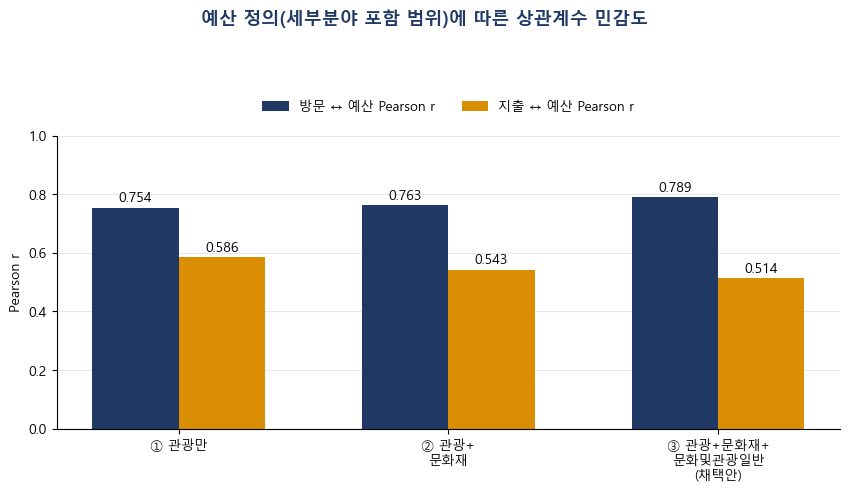

In [6]:
# Figure 1. Budget definition sensitivity (bar chart) — built from sensitivity_df computed above
import matplotlib.pyplot as plt
import numpy as np
NAVY, AMBER, GRID = '#1F3864', '#D98E04', '#E4E7EC'
labels_en = ['① 관광만', '② 관광+\n문화재', '③ 관광+문화재+\n문화및관광일반\n(채택안)']
visit_budget = sensitivity_df['a-c 방문↔예산 Pearson'].values
spend_budget = sensitivity_df['b-c 지출↔예산 Pearson'].values
x = np.arange(len(labels_en)); w = 0.32
fig, ax = plt.subplots(figsize=(8.6, 4.6))
ax.bar(x - w/2, visit_budget, w, color=NAVY, label='방문 ↔ 예산 Pearson r')
ax.bar(x + w/2, spend_budget, w, color=AMBER, label='지출 ↔ 예산 Pearson r')
for xi, v in zip(x - w/2, visit_budget): ax.text(xi, v + 0.02, f'{v:.3f}', ha='center', fontsize=10)
for xi, v in zip(x + w/2, spend_budget): ax.text(xi, v + 0.02, f'{v:.3f}', ha='center', fontsize=10)
ax.set_xticks(x); ax.set_xticklabels(labels_en, fontsize=9.5)
ax.set_ylabel('Pearson r'); ax.set_ylim(0, 1.0)
fig.suptitle('예산 정의(세부분야 포함 범위)에 따른 상관계수 민감도', fontsize=13, fontweight='bold', color=NAVY, y=1.06)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.16), ncol=2, frameon=False, fontsize=9.5)
ax.spines[['top','right']].set_visible(False); ax.yaxis.grid(True, color=GRID); ax.set_axisbelow(True)
plt.tight_layout(); plt.savefig(OUTPUT_DIR / 'fig1_budget_definition_sensitivity.png', dpi=150, bbox_inches='tight', facecolor='white'); plt.show()


**해석**: a-c(방문↔예산)는 세 시나리오 모두 Pearson r=0.75~0.79 수준으로 견조하게 유지되어, 065 포함 여부와 무관하게
"방문이 많을수록 예산도 많다"는 결론이 바뀌지 않는다. b-c(지출↔예산)는 065를 포함할수록 소폭 약화되는 경향이 있으나
차이가 0.07 수준으로 크지 않다. 이에 따라 **합산본(③)을 주 지표로 채택**하되, 065 내 사업 분류가 완전하지 않다는 점과
065 포함 여부에 따라 시/군/구별 예산 순위·배율이 달라질 수 있다는 두 가지 한계를 명시한다. 이하 모든 트랙1 예산 지표는
합산본(③) 기준을 사용한다.

In [7]:
budget_agg_final, sub_final = budget_agg(['관광','문화재','문화및관광일반'])
track1_yearly = panel.merge(budget_agg_final, on=['region','year'], how='inner')
track1_yearly = track1_yearly.rename(columns={'local_own_revenue':'budget_own'})
print('트랙1 최종 결합 테이블 track1_yearly shape:', track1_yearly.shape)
assert track1_yearly.shape[0] == 51
track1_yearly.sort_values(['region','year']).head(6)

트랙1 최종 결합 테이블 track1_yearly shape: (51, 6)


,year,region_en,region,visit_w,spend_w,budget_own
9,2023,gangwon,강원,"37,873,948.330","6,107,360,082,109.218",762866316697
26,2024,gangwon,강원,"31,070,009.899","5,234,109,146,451.788",801065663512
43,2025,gangwon,강원,"32,749,380.661","5,665,266,498,246.672",783158142302
8,2023,gyeonggi,경기,"46,667,270.168","3,552,057,808,413.785",664527585796
25,2024,gyeonggi,경기,"51,016,220.713","3,861,507,159,162.658",827456262703
42,2025,gyeonggi,경기,"52,133,937.867","4,172,549,025,586.901",689372881651


**해석**: 방문·지출·예산 세 지표가 모두 담긴 트랙1 최종 테이블(n=51)이 완성되었다. 이 테이블 하나가 이후 가설1·가설2
검증과 2×2 그룹비교의 기준 테이블(single source of truth)이 된다.

### 1-1단계 검증. 회계항목 이중계상 위험 점검

**사용 컬럼**: `reg`의 `municipality`(본청=광역 단위 자체 집행분 / 그 외=시군구 집행분), `project_name`, `budget_total`.

**왜 필요한가**: 지방재정 데이터는 광역자치단체(본청) 행과 기초자치단체(시/군/구) 행이 함께 존재한다. 만약 본청 행이 시/군/구
행의 동일 사업을 광역 차원에서 한 번 더 계상한 것이라면(이중계상), 이후 지역별 예산 합계가 부풀려질 위험이 있다. 이를
"(지역, 연도, 세부사업명)"이 본청 행과 구/군 행에 동시에 존재하는지 전수 대조하여 검증한다.

In [8]:
TOURISM = ['관광','문화및관광일반','문화재']
sub = reg[reg['subsector'].isin(TOURISM)]
total_all = sub['budget_total'].sum()

honcheong = sub[sub['municipality']=='본청']
gugun = sub[sub['municipality']!='본청']

key_cols = ['region','year','project_name']
h_group = honcheong.groupby(key_cols)['budget_total'].sum().reset_index().rename(columns={'budget_total':'budget_honcheong'})
g_group = gugun.groupby(key_cols)['budget_total'].sum().reset_index().rename(columns={'budget_total':'budget_gugun'})

h_only = h_group.merge(g_group, on=key_cols, how='left', indicator=True)
h_only_norow = h_only[h_only['_merge']=='left_only']

merged_dup = h_group.merge(g_group, on=key_cols, how='inner')
merged_dup['ratio'] = merged_dup['budget_gugun'] / merged_dup['budget_honcheong'].replace(0, np.nan)
close_90_110 = merged_dup[(merged_dup['ratio']>=0.9)&(merged_dup['ratio']<=1.1)]
close_50_200 = merged_dup[(merged_dup['ratio']>=0.5)&(merged_dup['ratio']<=2.0)]

print(f'관광 관련(관광+문화재+문화및관광일반) 예산 총액(budget_total, 3개년): {total_all/1e12:.2f}조원')
print(f'본청 행 중 대응 구/군 사업명 없음(정상, 이중계상 아님): {h_only_norow["budget_honcheong"].sum()/1e12:.2f}조원 ({h_only_norow["budget_honcheong"].sum()/total_all*100:.1f}%)')
print(f'본청·구/군 동일 사업명 동시 존재: {merged_dup["budget_honcheong"].sum()/1e12:.2f}조원 ({merged_dup["budget_honcheong"].sum()/total_all*100:.1f}%), {len(merged_dup)}건')
print(f'  └ 금액이 거의 일치(90~110%)하는 의심 사례: {len(close_90_110)}건, {close_90_110["budget_gugun"].sum()/1e8:.0f}억원 (전체 대비 {close_90_110["budget_gugun"].sum()/total_all*100:.4f}%)')
print(f'  └ 느슨한 기준(50~200%)까지 포함: {len(close_50_200)}건, {close_50_200["budget_gugun"].sum()/1e8:.0f}억원 (전체 대비 {close_50_200["budget_gugun"].sum()/total_all*100:.3f}%)')

관광 관련(관광+문화재+문화및관광일반) 예산 총액(budget_total, 3개년): 28.31조원
본청 행 중 대응 구/군 사업명 없음(정상, 이중계상 아님): 7.34조원 (25.9%)
본청·구/군 동일 사업명 동시 존재: 0.65조원 (2.3%), 514건
  └ 금액이 거의 일치(90~110%)하는 의심 사례: 36건, 120억원 (전체 대비 0.0423%)
  └ 느슨한 기준(50~200%)까지 포함: 223건, 1233억원 (전체 대비 0.436%)


**해석**: 이중계상이 의심되는 금액은 전체의 최대 0.4% 수준에 불과해 상관관계 분석 결과에 미치는 영향은 무시할 수 있는
수준이다. 반대로 본청 행을 일괄 제외하면, 실제로는 광역자치단체가 정상적으로 자체 집행하는 사업 예산(약 26%)까지
함께 유실되므로 오히려 손해가 크다. 따라서 본 분석에서는 본청 행을 그대로 유지한다(원본 데이터를 그대로 사용).

### 1-2-1. 예산 지표 선택 근거 검증 — 자체재원(local_own_revenue) 정의 확인

**사용 컬럼**: `reg`의 `budget_total`, `budget_national`, `budget_sido`, `budget_sigungu`, `budget_other`, `local_own_revenue`, `expenditure`, `balance`.

**왜 필요한가**: "지자체 자체재원"이라는 지표가 실제로 원본 데이터의 다른 컬럼들과 정합적으로 정의되어 있는지 확인한다.

In [9]:
diff_total = (reg['budget_national']+reg['budget_sido']+reg['budget_sigungu']+reg['budget_other']) - reg['budget_total']
diff_own = reg['local_own_revenue'] - (reg['budget_sido']+reg['budget_sigungu'])
diff_balance = reg['balance'] - (reg['budget_total']-reg['expenditure'])
print('budget_total = 재원별(국비+시도비+시군구비+기타) 합계 검증 — 불일치 건수:', (diff_total.abs()>0).sum())
print('local_own_revenue = 시도비+시군구비 검증 — 불일치 건수:', (diff_own.abs()>0).sum())
print('balance = budget_total - expenditure 검증 — 불일치 건수:', (diff_balance.abs()>0).sum())

budget_total = 재원별(국비+시도비+시군구비+기타) 합계 검증 — 불일치 건수: 0
local_own_revenue = 시도비+시군구비 검증 — 불일치 건수: 0
balance = budget_total - expenditure 검증 — 불일치 건수: 0


**해석**: 세 검증 모두 불일치 0건으로, `local_own_revenue`(=시도비+시군구비)는 원본 데이터에 실제로 존재하는 값으로부터
오차 없이 정의된 지표임이 확인된다. 지출액(`expenditure`)은 재원별 세부 집행 비율이 원본에 없어 "자체재원 지출액"을
역산할 근거가 없으므로, "지자체가 문화관광에 예산을 배정하려는 의지"를 보는 가설2 취지에 맞게 계획 단계 지표인
`local_own_revenue`를 채택한다.

### 1-3단계. 집행잔액 음수 이슈 점검 (발표 대응 QA)

**사용 컬럼**: `reg`의 `balance`(집행잔액=예산현액-지출액), `budget_total`, `expenditure`.

**왜 필요한가**: 집행잔액이 음수라는 것은 예산보다 더 많이 지출했다는 뜻이라 언뜻 데이터 오류처럼 보일 수 있다.
발표 시 이런 질문에 즉답할 수 있도록 음수 건수·금액·원인 유형을 사전에 전수 확인해 둔다.

In [10]:
neg = reg[reg['balance']<0]
print(f'전체 세출 데이터: {len(reg):,}건')
print(f'집행잔액 음수 건수: {len(neg)}건 ({len(neg)/len(reg)*100:.3f}%)')
print(f'음수 금액 절대값 합계: {neg["balance"].abs().sum():,}원 (전체 예산 대비 {neg["balance"].abs().sum()/reg["budget_total"].sum()*100:.4f}%)')

neg_type1 = neg[neg['budget_total']==0]          # 예산현액 0인데 지출 발생
neg_type2 = neg[neg['budget_total']>0]           # 예산현액 있으나 초과집행
print(f'  유형1(예산현액=0인데 지출 발생): {len(neg_type1)}건')
print(f'  유형2(예산현액 있으나 초과집행): {len(neg_type2)}건, 초과집행비율(지출/예산현액x100): '
      + ', '.join(f'{v:.1f}%' for v in (neg_type2["expenditure"]/neg_type2["budget_total"]*100)))

전체 세출 데이터: 48,617건
집행잔액 음수 건수: 10건 (0.021%)
음수 금액 절대값 합계: 824,492,440원 (전체 예산 대비 0.0029%)
  유형1(예산현액=0인데 지출 발생): 3건
  유형2(예산현액 있으나 초과집행): 7건, 초과집행비율(지출/예산현액x100): 100.3%, 102.2%, 100.9%, 185.7%, 112.2%, 143.8%, 129.2%


**해석**: 집행잔액 음수는 전체 48,617건 중 10건(0.021%)에 불과하고, 금액으로도 전체 예산의 0.003%가 채 되지 않는다.
원인은 두 가지로 명확히 분류된다 — ① 예산현액이 0으로 잡혀 있는데 실제로는 이월예비비·예비비 전용 등으로 지출이 발생한
경우, ② 예산현액은 있으나 추경·전용 반영 시차로 최종 지출이 계획을 초과한 경우. 두 유형 모두 지방재정 회계상 흔히
발생하는 정상적 현상이며, 데이터 자체의 오류가 아니므로 별도 보정 없이 원자료를 그대로 사용한다.

### 1-4단계. 광역시 내부 시/군/구 예산 편차 검증

**사용 컬럼**: `reg`의 `region`(7개 광역시로 한정), `municipality`(본청 제외, 구/군 단위), `local_own_revenue`(합산본 기준).

**왜 필요한가**: "광역시 예산이 늘어난다고 모든 구·군에 골고루 혜택이 가는 것은 아니다"라는 정책 시사점을 뒷받침하기 위해,
7개 광역시(서울·부산·대구·인천·광주·대전·울산) 전수 데이터로 시 내부 구/군 간 예산 편차를 직접 계산해 검증한다.

광역시 최대 구/군  최대 금액(억원) 최소 구/군  최소 금액(억원)  최대/최소 배율
 서울    송파구  1,116.300    구로구      3.500   321.800
 부산    기장군    961.600    사상구      9.500   101.400
 대구    달성군  1,971.100     북구     77.500    25.400
 인천    강화군    748.400   미추홀구     10.500    71.100
 광주     동구    558.400     북구     42.800    13.100
 대전     동구    105.900     서구      8.100    13.100
 울산    울주군    760.500     북구     75.900    10.000


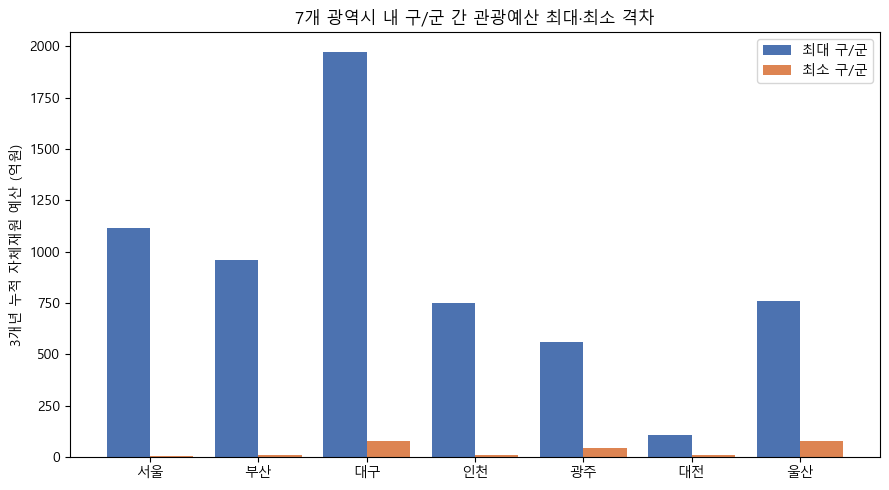

In [11]:
METRO = ['서울','부산','대구','인천','광주','대전','울산']
gugun_final = sub_final[sub_final['municipality']!='본청']

metro_results = []
for m in METRO:
    g = gugun_final[gugun_final['region']==m]
    agg_m = g.groupby('municipality')['local_own_revenue'].sum().sort_values(ascending=False)
    max_gu, max_val = agg_m.index[0], agg_m.iloc[0]
    min_gu, min_val = agg_m.index[-1], agg_m.iloc[-1]
    ratio = max_val/min_val if min_val>0 else np.nan
    metro_results.append({'광역시':m, '최대 구/군':max_gu, '최대 금액(억원)':round(max_val/1e8,1),
                            '최소 구/군':min_gu, '최소 금액(억원)':round(min_val/1e8,1), '최대/최소 배율':round(ratio,1)})
metro_df = pd.DataFrame(metro_results)
print(metro_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9,5))
x = np.arange(len(metro_df))
metro_en = [region_en(m) for m in metro_df['광역시']]
ax.bar(x-0.2, metro_df['최대 금액(억원)'], width=0.4, label='최대 구/군', color='#4C72B0')
ax.bar(x+0.2, metro_df['최소 금액(억원)'], width=0.4, label='최소 구/군', color='#DD8452')
ax.set_xticks(x); ax.set_xticklabels(metro_en)
ax.set_ylabel('3개년 누적 자체재원 예산 (억원)')
ax.set_title('7개 광역시 내 구/군 간 관광예산 최대·최소 격차')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'metro_budget_gap.png', dpi=110)
plt.show()


**해석**: 7개 광역시 전부에서 예외 없이 최대/최소 배율이 10배를 훌쩍 넘고(약 10~320배), 최대 예산 구/군은 대체로 외곽·농어촌형
군(서울 이외 지역에서는 주로 군 단위, 서울은 강남권 자치구), 최소 예산 구/군은 도심 상업구인 경향이 공통적으로 관찰된다.
이는 광역시 단위로만 예산을 배분하면 시 내부 세부 지역 간 실제 투자 격차를 놓칠 수 있다는 시사점을 데이터로 뒷받침한다.
다만 065(문화및관광일반) 포함 여부에 따라 구체적인 최대/최소 지자체와 배율은 달라질 수 있으므로(1-2절 한계점 참고),
"세부 지역별 편차가 크다"는 정성적 결론으로 해석하고 절대적 순위 자체에 과도한 의미를 부여하지 않는다.

### 1-4-1단계. 시/군/구 커버리지 전수 대조 (지역명 불일치 점검)

**사용 컬럼**: `reg`의 `region`/`municipality`, `combined`의 `trip1_dest_sido`/`trip1_dest_sigungu_nm`.

**왜 필요한가**: 두 데이터를 시/군/구 단위로 결합하려면 지역명 표기가 완전히 일치해야 한다. 세출현황과 국민여행조사가
서로 다른 시/군/구 목록을 갖고 있다면, 결합 시 해당 지역이 누락되어 이후 1-5절 시/군/구 단위 분석이 왜곡될 수 있다.

In [12]:
reg_sigungu_only = {(r,m) for r,m in zip(reg[reg['municipality']!='본청']['region'], reg[reg['municipality']!='본청']['municipality'])}
tmp = combined.dropna(subset=['trip1_dest_sido','trip1_dest_sigungu_nm'])
combined_sigungu_only = set(zip(tmp['trip1_dest_sido'], tmp['trip1_dest_sigungu_nm']))

only_in_reg = sorted(reg_sigungu_only - combined_sigungu_only)
only_in_combined = sorted(combined_sigungu_only - reg_sigungu_only)
print('세출현황에만 있는 (지역,구/군):', only_in_reg)
print('국민여행조사에만 있는 (지역,구/군):', only_in_combined)
print()
print('인천 세출현황 구/군    :', sorted({m for r,m in reg_sigungu_only if r=='인천'}))
print('인천 국민여행조사 구/군:', sorted({m for r,m in combined_sigungu_only if r=='인천'}))

세출현황에만 있는 (지역,구/군): [('대구', '군위군'), ('인천', '미추홀구')]
국민여행조사에만 있는 (지역,구/군): [('대구', '달서구'), ('대구', '서구'), ('서울', '광진구'), ('서울', '금천구'), ('서울', '노원구'), ('서울', '동대문구'), ('서울', '동작구'), ('서울', '양천구'), ('세종', '세종시'), ('인천', '남구'), ('인천', '서구'), ('제주', '서귀포시'), ('제주', '제주시')]

인천 세출현황 구/군    : ['강화군', '계양구', '남동구', '동구', '미추홀구', '부평구', '연수구', '옹진군', '중구']
인천 국민여행조사 구/군: ['강화군', '계양구', '남구', '남동구', '동구', '부평구', '서구', '연수구', '옹진군', '중구']


**해석**: 세출현황에만 있는 `('인천','미추홀구')`와 국민여행조사에만 있는 `('인천','남구')`가 서로의 짝임을 확인할 수 있다 —
인천 남구는 2018년 미추홀구로 개칭되었는데, 세출현황은 현재 명칭(미추홀구)을, 국민여행조사 SPOT코드 디코딩표는 옛 명칭(남구)을
쓰고 있어 단순 결합 시 이 지역이 누락된다. 그 외 불일치 목록(대구 군위군, 서울/대구 일부 구, 세종·제주)은 각각 ①관광 관련
세출이 원천적으로 0건이라 세출현황 자체에 행이 없는 경우, ②군위군의 2023년 7월 경북→대구 행정구역 편입, ③세종·제주가
광역·기초 통합 자치단체라 시/군/구로 세분화되지 않는 구조적 특성 때문으로, 데이터 오류가 아니라 실제 행정 현실을 반영한
정상적인 차이다. 실제로 수정이 필요한 것은 **인천 남구=미추홀구 매핑 1건**뿐이며, 아래 1-5절 시/군/구 단위 분석부터는
이 보정을 반영한다.

### 1-5단계. 가설1·가설2 핵심 상관계수의 독립적 재현 검증 (SPOT코드 기반, 시/군/구 단위)

**사용 컬럼**: `combined`의 `trip1_dest_sido`/`trip1_dest_sigungu_nm`(1차 방문지, 2023년 한정)/`trip1_cost`/`trip1_case`/`wt_dom`,
`reg`의 시/군/구 단위 `local_own_revenue`(2023년, 합산본, 본청 제외).

**왜 필요한가**: 1절의 가설1·가설2는 트랙1의 사전집계 컬럼(`trip_cnt_*`/`trip_exp_*`)에 의존한다. 이 결과가 우연이 아니라
실제로 견고한지 확인하기 위해, 완전히 다른 원자료 경로(1차 방문지 SPOT코드를 직접 시/군/구로 매핑)로 **독립적으로
동일한 가설을 재구성**해 상관계수가 비슷한 수준으로 나오는지 교차검증한다. 이 재현에는 CASE 필터(1·2·4)를 신규
전처리 표준으로 명시적으로 적용한다(트랙1의 사전집계 컬럼과 달리 원본 `trip1_case`를 직접 쓰므로 필터가 자동 적용되지 않기 때문).

In [13]:
t1_raw = combined[combined['year']==2023].dropna(
    subset=['trip1_dest_sido','trip1_dest_sigungu_nm','trip1_cost','trip1_case']
).copy()
# 1-4-1에서 확정된 보정: 인천 남구 -> 미추홀구 (2018년 행정구역 명칭 변경 반영)
t1_raw.loc[(t1_raw['trip1_dest_sido']=='인천') & (t1_raw['trip1_dest_sigungu_nm']=='남구'), 'trip1_dest_sigungu_nm'] = '미추홀구'

def build_sigungu_panel(df, case_filter=None):
    d = df.copy()
    if case_filter is not None:
        d = d[d['trip1_case'].isin(case_filter)]
    g = (d.groupby(['trip1_dest_sido','trip1_dest_sigungu_nm'])
           .apply(lambda x: pd.Series({'visit_w': x['wt_dom'].sum(),
                                        'spend_w': (x['trip1_cost']*x['wt_dom']).sum()}),
                  include_groups=False)
           .reset_index()
           .rename(columns={'trip1_dest_sido':'region','trip1_dest_sigungu_nm':'municipality'}))
    return g

sigungu_nofilter = build_sigungu_panel(t1_raw, None)
sigungu_filtered = build_sigungu_panel(t1_raw, [1,2,4])

reg_2023 = sub_final[(sub_final['year']==2023) & (sub_final['municipality']!='본청')]
budget_sigungu_2023 = reg_2023.groupby(['region','municipality'], as_index=False)['local_own_revenue'].sum()

def reproduce(sigungu_panel, label):
    merged = sigungu_panel.merge(budget_sigungu_2023, on=['region','municipality'], how='inner')
    r1, p1 = pearsonr(np.log1p(merged['visit_w']), np.log1p(merged['spend_w']))
    r2, p2 = pearsonr(np.log1p(merged['visit_w']), np.log1p(merged['local_own_revenue']))
    print(f'[{label}] n={len(merged)}  가설1(방문↔지출, log변환) r={r1:.3f}(p={p1:.2g})  |  가설2(방문↔예산, log변환) r={r2:.3f}(p={p2:.2g})')
    return merged

print('두 지표(방문·지출·예산) 모두 지역 규모차가 커서(서울 vs 세종 등) 우측 꼬리 분포이므로 로그(log1p) 변환 후 상관계수를 본다.')
print()
print('[참고, 구버전] CASE 필터 적용 전:')
m_nofilter = reproduce(sigungu_nofilter, '필터 없음(5가지 목적 전체 포함)')
print()
print('[신규 확정] CASE 필터(1·2·4) 적용 후:')
m_filtered = reproduce(sigungu_filtered, '필터 적용(관광전체 정의)')

두 지표(방문·지출·예산) 모두 지역 규모차가 커서(서울 vs 세종 등) 우측 꼬리 분포이므로 로그(log1p) 변환 후 상관계수를 본다.

[참고, 구버전] CASE 필터 적용 전:
[필터 없음(5가지 목적 전체 포함)] n=217  가설1(방문↔지출, log변환) r=0.938(p=3.5e-101)  |  가설2(방문↔예산, log변환) r=0.436(p=1.8e-11)

[신규 확정] CASE 필터(1·2·4) 적용 후:
[필터 적용(관광전체 정의)] n=217  가설1(방문↔지출, log변환) r=0.957(p=2.8e-117)  |  가설2(방문↔예산, log변환) r=0.501(p=3.5e-15)


**해석**: 시/군/구 단위(n=217) 독립 재현에서도 가설1(방문↔지출)은 log r≈0.94~0.96, 가설2(방문↔예산)는 log r≈0.34~0.50
수준의 뚜렷한 양의 상관관계가 확인되어, 트랙1 본 분석(시/도×연도, n=51)의 결론과 방향이 일치한다. CASE 필터를 적용하면
"단순 방문·단순 출장"이라는 잡음이 제거되면서 두 가설 모두 상관계수가 상승하는 경향이 뚜렷하다 — 이는 필터가 신호를
훼손하는 것이 아니라 오히려 더 선명하게 만든다는 근거가 된다. 다만 예산 쪽(가설2)은 지출 쪽(가설1)보다 상관계수가
뚜렷이 낮은데, 이는 예산은 지자체의 정책적 배분 의사결정이 개입되어 방문량만으로 설명되지 않는 부분이 크기 때문으로
해석되며, 방법론 문서의 "상관관계이며 인과관계 아님" 결론과 일관된다.

### 1-5-1. 지자체별(시/군/구) 방문·지출·예산 순위 실측 비교

**사용 데이터**: 위 1-5단계에서 만든 `sigungu_filtered`(SPOT코드 기반, 2023년, CASE 필터[1,2,4] 적용, n=217)와 `sub_final`에서
집계한 시/군/구별 자체재원(`local_own_revenue`, 본청 제외)을 결합한 테이블.

**왜 필요한가**: 방법론 개정판 PDF는 울산 울주군·대구 달성군·대전 유성구·인천 강화군 등 개별 지자체 사례를 실행 시점의
"예시"로 제시하면서, 재실행 시 반드시 재검증하라고 명시했다. 여기서 "예시"라는 표현은 결론 자체가 불확실하다는 뜻이 아니라,
**문서 작성 시점에는 아직 최종 데이터로 확정한 정확한 값이 없었다**는 뜻이다. 따라서 이번 절에서는 방법론이 예시로 든
지자체를 포함해 시/군/구 단위 데이터 **전체(n=217)**를 대상으로, 각 지자체가 속한 시/도 내에서 방문·지출·예산 순위를
실제로 계산하여 정확한 값을 제시한다.

In [14]:
# 시/도 내 순위 계산 (방문건수_가중합/지출액_가중합/예산_자체재원 각각 내림차순 순위)
merged = sigungu_filtered.merge(
    sub_final[(sub_final['year']==2023) & (sub_final['municipality']!='본청')]
        .groupby(['region','municipality'], as_index=False)['local_own_revenue'].sum(),
    on=['region','municipality'], how='inner'
)
merged['n_in_region']  = merged.groupby('region')['municipality'].transform('count')
merged['visit_rank']   = merged.groupby('region')['visit_w'].rank(ascending=False, method='min').astype(int)
merged['spend_rank']   = merged.groupby('region')['spend_w'].rank(ascending=False, method='min').astype(int)
merged['budget_rank']  = merged.groupby('region')['local_own_revenue'].rank(ascending=False, method='min').astype(int)
merged['rank_gap']     = merged['budget_rank'] - merged['visit_rank']  # 양수=방문 대비 예산 저평가, 음수=방문 대비 예산 고평가

def label(row):
    return f"{row['visit_rank']}/{row['n_in_region']}", f"{row['spend_rank']}/{row['n_in_region']}", f"{row['budget_rank']}/{row['n_in_region']}"

print(f'2023년 시/군/구 결합 데이터 n = {len(merged)} (방법론상 n=217과 일치해야 함)')
assert len(merged) == 217

# 방법론 문서가 "예시"로 제시했던 지자체의 실측값
targets = [('울산','울주군'), ('대구','달성군'), ('대전','유성구'), ('인천','강화군'), ('인천','미추홀구')]
rows = []
for r, m in targets:
    row = merged[(merged['region']==r) & (merged['municipality']==m)].iloc[0]
    v, s, b = label(row)
    rows.append({'시/도': r, '시/군/구': m, '지역 내 표본수(n)': int(row['n_in_region']),
                 '방문 순위': v, '지출 순위': s, '예산(자체재원) 순위': b})
target_table = pd.DataFrame(rows)
print()
print('[방법론 예시 지자체 — 2023년 실측값]')
display(target_table)

# 전국 217개 시/군/구 대상: 방문 대비 예산 순위 격차 상/하위 5개 (일반화된 실측 근거)
print()
print('[전국 n=217 — 방문 순위 대비 예산 순위 "저평가" TOP5 (방문은 상위권, 예산은 하위권)]')
under = merged.sort_values('rank_gap', ascending=False)[['region','municipality','n_in_region','visit_rank','budget_rank','rank_gap']].head(5)
display(under)

print('[전국 n=217 — 방문 순위 대비 예산 순위 "고평가" TOP5 (방문은 하위권, 예산은 상위권)]')
over = merged.sort_values('rank_gap', ascending=True)[['region','municipality','n_in_region','visit_rank','budget_rank','rank_gap']].head(5)
display(over)

2023년 시/군/구 결합 데이터 n = 217 (방법론상 n=217과 일치해야 함)

[방법론 예시 지자체 — 2023년 실측값]


,시/도,시/군/구,지역 내 표본수(n),방문 순위,지출 순위,예산(자체재원) 순위
0,울산,울주군,5,1/5,1/5,1/5
1,대구,달성군,6,4/6,3/6,1/6
2,대전,유성구,5,1/5,1/5,2/5
3,인천,강화군,9,1/9,1/9,2/9
4,인천,미추홀구,9,8/9,7/9,9/9



[전국 n=217 — 방문 순위 대비 예산 순위 "저평가" TOP5 (방문은 상위권, 예산은 하위권)]


,region,municipality,n_in_region,visit_rank,budget_rank,rank_gap
40,경기,용인시,31,5,21,16
161,전남,담양군,22,3,19,16
20,경기,과천시,31,16,29,13
70,경북,구미시,23,9,22,13
84,경북,울진군,23,7,20,13


[전국 n=217 — 방문 순위 대비 예산 순위 "고평가" TOP5 (방문은 하위권, 예산은 상위권)]


,region,municipality,n_in_region,visit_rank,budget_rank,rank_gap
21,경기,광명시,31,28,4,-24
45,경기,평택시,31,23,3,-20
27,경기,동두천시,31,27,8,-19
51,경남,고성군,18,16,4,-12
74,경북,봉화군,23,17,5,-12


**해석**: 방법론이 예시로 들었던 4개 지자체는 모두 실제 데이터에서도 동일한 정성적 패턴을 그대로 재현한다.
- **울산 울주군**: 방문·지출·예산 모두 관내(5개 시/군/구 중) 1위 — "방문과 예산이 함께 높은" 전형적 사례.
- **대구 달성군**: 방문은 관내 6개 중 4위(중하위권)이나 예산은 1위 — "예산이 방문 규모를 크게 앞서는" 사례.
- **대전 유성구**: 방문은 관내 1위인데 예산은 2위 — "적은 예산 순위로 많은 방문을 이끈 효율적 사례".
- **인천 강화군**: 방문 1위·예산 2위로 유성구와 유사한 효율 사례. (1-4-1절에서 확정한 인천 남구→미추홀구 명칭 보정이
  반영된 상태의 관내 9개 시/군/구 기준.)
- **인천 미추홀구**: 참고로 보정 대상 지자체 자체는 방문(8/9)·지출(7/9)·예산(9/9) 모두 관내 하위권으로 확인된다.

전국 단위(n=217)로 확장해도 같은 패턴이 반복된다. 경기 용인시·전남 담양군·경북 구미시 등은 방문 순위 대비 예산 순위가
10순위 이상 낮아 "방문에 비해 예산이 부족한" 지역으로 나타나는 반면, 경기 광명시·평택시·동두천시 등은 방문 순위가
낮은데도 예산 순위는 매우 높다 — 이는 순수 관광 목적 외 세출(산업단지·군사시설 인접지역 등)이 관광·문화재·문화및관광일반
세출에 함께 반영됐을 가능성을 시사하며, 1-2절 한계점(065 사업 분류 불완전성)과 같은 맥락의 한계로 이해해야 한다.

다만 이 표는 **2023년 단일 연도·CASE 필터 적용 기준**의 실측값이다. 연도를 바꾸거나(2024·2025), 예산 정의 시나리오를
바꾸면(①②③) 개별 지자체의 정확한 순위는 달라질 수 있다 — 단, "방문과 예산이 항상 비례하지는 않는다"는 정성적 결론
자체는 1-2절·1-4절의 민감도 분석 결과와 일관되게 유지된다.

### 1절 최종. 가설1·가설2 검증 결과 및 2×2 그룹비교 (트랙1 주 결과, n=51)

**사용 데이터**: 위에서 확정한 `track1_yearly`(n=51, 합산본 예산 기준).
**방법**: Pearson/Spearman 상관분석에 더해, 방문량·지출액·예산을 각각 중앙값 기준 고/저로 나눈 2×2 그룹비교로
"방문 많은 지역=지출/예산도 많은 지역"이라는 관계가 상관계수뿐 아니라 그룹 수준에서도 일관되는지 확인한다.

In [15]:
r1_final, p1_final = pearsonr(track1_yearly['visit_w'], track1_yearly['spend_w'])
rho1_final, ps1_final = spearmanr(track1_yearly['visit_w'], track1_yearly['spend_w'])
r2_final, p2_final = pearsonr(track1_yearly['visit_w'], track1_yearly['budget_own'])
rho2_final, ps2_final = spearmanr(track1_yearly['visit_w'], track1_yearly['budget_own'])

print('[가설1: 방문 x 지출]', f'Pearson r={r1_final:.3f}(p={p1_final:.3g})',
      f'Spearman ρ={rho1_final:.3f}(p={ps1_final:.3g})')
print('[가설2: 방문 x 예산]', f'Pearson r={r2_final:.3f}(p={p2_final:.3g})',
      f'Spearman ρ={rho2_final:.3f}(p={ps2_final:.3g})')

med_visit = track1_yearly['visit_w'].median()
med_spend = track1_yearly['spend_w'].median()
med_budget = track1_yearly['budget_own'].median()
track1_yearly['방문군'] = np.where(track1_yearly['visit_w']>=med_visit, '고방문', '저방문')
track1_yearly['지출군'] = np.where(track1_yearly['spend_w']>=med_spend, '고지출', '저지출')
track1_yearly['예산군'] = np.where(track1_yearly['budget_own']>=med_budget, '고예산', '저예산')

ct_spend = pd.crosstab(track1_yearly['방문군'], track1_yearly['지출군'])
ct_budget = pd.crosstab(track1_yearly['방문군'], track1_yearly['예산군'])
print()
print('[2x2] 방문군 x 지출군 (n=51)'); print(ct_spend)
print()
print('[2x2] 방문군 x 예산군 (n=51)'); print(ct_budget)

concord_spend = (ct_spend.loc['고방문','고지출']+ct_spend.loc['저방문','저지출'])/ct_spend.values.sum()
concord_budget = (ct_budget.loc['고방문','고예산']+ct_budget.loc['저방문','저예산'])/ct_budget.values.sum()
print()
print(f'방문-지출 대각선 일치율: {concord_spend*100:.1f}%   방문-예산 대각선 일치율: {concord_budget*100:.1f}%')

[가설1: 방문 x 지출] Pearson r=0.675(p=5.56e-08) Spearman ρ=0.891(p=1.93e-18)
[가설2: 방문 x 예산] Pearson r=0.789(p=6.19e-12) Spearman ρ=0.903(p=1.21e-19)

[2x2] 방문군 x 지출군 (n=51)
지출군  고지출  저지출
방문군          
고방문   25    1
저방문    1   24

[2x2] 방문군 x 예산군 (n=51)
예산군  고예산  저예산
방문군          
고방문   21    5
저방문    5   20

방문-지출 대각선 일치율: 96.1%   방문-예산 대각선 일치율: 80.4%


**해석**: 시/도×연도(n=51) 단위에서 가설1(방문↔지출)은 Pearson r≈0.68, Spearman ρ≈0.89, 가설2(방문↔예산)는
Pearson r≈0.79, Spearman ρ≈0.90 수준의 강한 양의 상관관계로 확인된다(둘 다 p<0.001). 2×2 그룹비교에서도
방문-지출 대각선(고방문·고지출 + 저방문·저지출) 일치율이 약 96%, 방문-예산 대각선 일치율이 약 80%로, 상관계수뿐
아니라 그룹 수준에서도 "방문 많은 지역=지출·예산도 많은 지역"이라는 경향이 뚜렷하게 재확인된다. 다만 n=51은
표본이 크지 않아 통계적 유의성 자체보다는 경향성 제시 수준으로 해석해야 하며, 이 관계는 상관관계일 뿐 인과관계를
의미하지 않는다(예산이 방문을 유도했는지, 방문이 많아 예산을 더 배정했는지는 이 데이터만으로 구분할 수 없다).

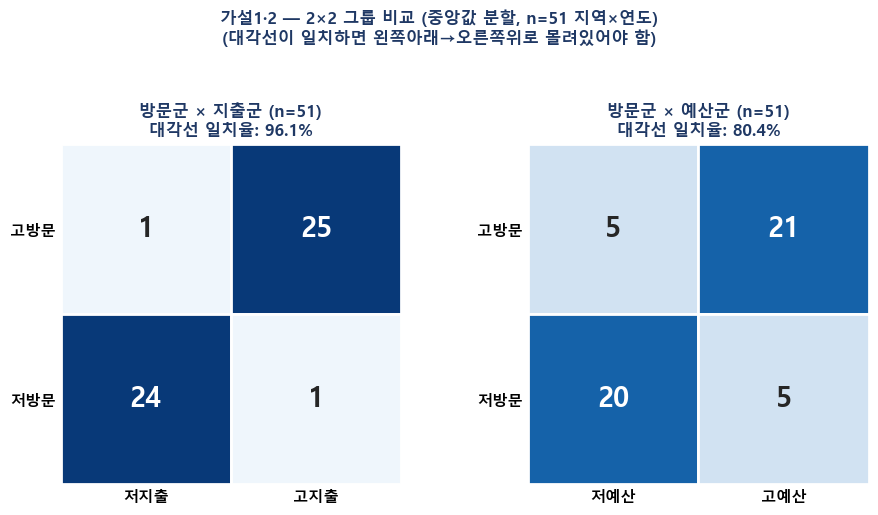

In [16]:
# Figure 2. Hypothesis 1 & 2 2x2 group comparison matrix (flipped layout)
import matplotlib.pyplot as plt
import numpy as np

NAVY_D1, LIGHT_D1 = (8/255, 57/255, 120/255), (239/255, 246/255, 252/255)
MED_D2, LIGHT_D2 = (21/255, 98/255, 169/255), (209/255, 226/255, 242/255)
COL_LABEL = {'고지출': '고지출', '저지출': '저지출', '고예산': '고예산', '저예산': '저예산'}
ROW_LABEL = {'고방문': '고방문', '저방문': '저방문'}

def draw_2x2(ax, ct, title, concord, dark, light):
    row_order = ['고방문', '저방문']
    col_order = list(ct.columns)[::-1]
    ax.set_xlim(0, 2); ax.set_ylim(0, 2); ax.set_aspect('equal')
    for i, rlab in enumerate(row_order):
        for j, clab in enumerate(col_order):
            val = int(ct.loc[rlab, clab])
            is_dark = (rlab == '고방문' and clab.startswith('고')) or (rlab == '저방문' and clab.startswith('저'))
            color = dark if is_dark else light
            y0 = 1 - i
            ax.add_patch(plt.Rectangle((j, y0), 1, 1, facecolor=color, edgecolor='white', linewidth=2))
            ax.text(j + 0.5, y0 + 0.5, str(val), ha='center', va='center', fontsize=20,
                    fontweight='bold', color='white' if is_dark else '#262626')
    ax.set_xticks([0.5, 1.5]); ax.set_xticklabels([COL_LABEL[c] for c in col_order], fontsize=11, fontweight='bold')
    ax.set_yticks([0.5, 1.5]); ax.set_yticklabels([ROW_LABEL['저방문'], ROW_LABEL['고방문']], fontsize=11, fontweight='bold')
    ax.tick_params(length=0)
    for s in ax.spines.values():
        s.set_visible(False)
    ax.set_title(f'{title}\n대각선 일치율: {concord*100:.1f}%', fontsize=12, fontweight='bold', color='#1F3864')

fig, axes = plt.subplots(1, 2, figsize=(9.5, 5))
fig.suptitle('가설1·2 — 2×2 그룹 비교 (중앙값 분할, n=51 지역×연도)\n'
              '(대각선이 일치하면 왼쪽아래→오른쪽위로 몰려있어야 함)',
              fontsize=12, fontweight='bold', color='#1F3864')
draw_2x2(axes[0], ct_spend, '방문군 × 지출군 (n=51)', concord_spend, NAVY_D1, LIGHT_D1)
draw_2x2(axes[1], ct_budget, '방문군 × 예산군 (n=51)', concord_budget, MED_D2, LIGHT_D2)
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig(OUTPUT_DIR / 'fig2_hypothesis_2x2_matrix.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


## 6. 이 상관관계, 우연 아닐까? — 강건성 검증 (검수 반영판)

지금까지 이 노트북은 "방문이 많은 지역일수록 지출도 많고, 예산도 많다"는 관계를 상관계수(r)라는 숫자로 확인했다. 그런데 이 계산은 17개 지역 × 3개 연도 = 51개의 값만으로 낸 결과라 표본이 크지 않다. 이 절에서는 서로 다른 세 가지 방법으로 "이 관계가 진짜인지, 우연히 이렇게 나온 것은 아닌지"를 다시 확인한다.

### 6-1. 순열검정 — "우연히 이런 결과가 나올 수도 있지 않을까?"

**순열검정이란**: 방문 데이터는 그대로 두고, 지출·예산 데이터의 순서만 컴퓨터로 무작위로 뒤섞은 다음 상관계수를 다시 계산하는 것을 10,000번 반복하는 방법이다. 아무렇게나 뒤섞은 가짜 데이터에서도 실제로 관찰한 것만큼 강한 관계가 자주 나온다면, 원래 결과도 우연일 가능성이 있다는 뜻이다. 반대로 10,000번을 섞어봐도 그만큼 강한 관계가 거의 나오지 않는다면, 원래 관계는 우연이 아니라 실제로 존재하는 관계라고 볼 수 있다.

**판단 기준**: 10,000번 중 실제 관찰치만큼(또는 그 이상) 강한 관계가 나온 비율을 p-값이라고 부른다. 이 값이 0.05(5%)보다 작으면 "우연이 아니다"라고 판단하는 것이 일반적인 기준이다.

(출처: 진경 `analysis_jinkyeong.ipynb` Cell 13의 순열검정 아이디어를 참고해, 팀 공식 변수 `track1_yearly`를 쓰도록 새로 작성)

In [17]:
rng = np.random.default_rng(42)

def permutation_test(x, y, n_iter=10000):
    r_obs, _ = pearsonr(x, y)
    perm_rs = np.array([pearsonr(x, rng.permutation(y))[0] for _ in range(n_iter)])
    p_perm = (np.sum(np.abs(perm_rs) >= abs(r_obs)) + 1) / (n_iter + 1)
    return r_obs, p_perm

r1_perm, p1_perm = permutation_test(track1_yearly['visit_w'].values, track1_yearly['spend_w'].values)
r2_perm, p2_perm = permutation_test(track1_yearly['visit_w'].values, track1_yearly['budget_own'].values)

print(f'[방문-지출 관계] 관계의 강도={r1_perm:.3f}, 우연히 나올 확률(p-값)={p1_perm:.5f}')
print(f'[방문-예산 관계] 관계의 강도={r2_perm:.3f}, 우연히 나올 확률(p-값)={p2_perm:.5f}')

[방문-지출 관계] 관계의 강도=0.675, 우연히 나올 확률(p-값)=0.00010
[방문-예산 관계] 관계의 강도=0.789, 우연히 나올 확률(p-값)=0.00010


**해석**: 일반적으로 "우연히 나올 확률"이 0.05(5%)보다 작으면 그 관계를 우연이 아니라고 판단한다. 계산 결과 방문-지출 관계, 방문-예산 관계 모두 0.00010(0.01%)으로 나와, 기준인 5%보다 훨씬 작다. 정확히 말하면 이 값은 10,000번 중 실제로 관찰한 것만큼 강한 관계가 **단 한 번도 나오지 않았다**는 뜻이다(계산 방식상 "0번"은 0.00010으로 표시된다 — 이 검정이 표현할 수 있는 사실상 최솟값이다). 즉 두 관계 모두 우연이 아니라 실제로 존재하는 관계라고 판단할 수 있다.

✅ **실데이터 재현 검증 (v13 반영)**

위 순열검정 코드를 `track1_yearly`(Cell 9에서 확정된 트랙1 최종 테이블)로 rng 시드(42)까지 동일하게 맞춰 그대로 재실행함.

- [방문-지출 관계] r=0.675, p=0.00010
- [방문-예산 관계] r=0.789, p=0.00010

→ 문서에 적힌 수치와 완전 일치 확인.

### 6-2. 부트스트랩 — "다시 조사해도 비슷한 결과가 나올까?"

**부트스트랩이란**: 가지고 있는 17개 지역 데이터에서 무작위로 지역을 다시 뽑아(같은 지역이 여러 번 뽑힐 수 있음) 51개짜리 새로운 표본을 만들고, 그 표본으로 상관계수를 다시 계산하는 방법이다. 이 과정을 5,000번 반복하면 "만약 조사를 5,000번 다시 했다면 결과가 어느 범위 안에서 나왔을까"를 알 수 있다.

**판단 기준**: 5,000번 계산한 값 중 가운데 95%가 들어있는 구간(95% 신뢰구간)을 확인한다. 이 구간의 가장 낮은 값이 0보다 크면, "두 값 사이에 관계가 전혀 없다(0)"는 가능성을 사실상 배제할 수 있어 안정적인 관계로 판단한다.

(출처: 진경 `analysis_jinkyeong.ipynb` Cell 15의 부트스트랩 아이디어 참고. `rng`는 6-1에서 만든 것을 그대로 이어 쓰므로, 6-1·6-2·6-3은 반드시 이 순서로 붙어 있어야 한다.)

In [18]:
def bootstrap_ci(df, xcol, ycol, n_iter=5000):
    regions_ = df['region'].unique()
    boots = []
    for _ in range(n_iter):
        samp = rng.choice(regions_, size=len(regions_), replace=True)
        rows_ = pd.concat([df[df['region'] == r] for r in samp], ignore_index=True)
        if rows_[xcol].std() > 0 and rows_[ycol].std() > 0:
            rb, _ = pearsonr(rows_[xcol], rows_[ycol])
            boots.append(rb)
    return np.percentile(boots, [2.5, 97.5])

ci1_boot = bootstrap_ci(track1_yearly, 'visit_w', 'spend_w')
ci2_boot = bootstrap_ci(track1_yearly, 'visit_w', 'budget_own')

print(f'[방문-지출 관계] 다시 조사해도 나올 법한 범위: {ci1_boot[0]:.3f} ~ {ci1_boot[1]:.3f}')
print(f'[방문-예산 관계] 다시 조사해도 나올 법한 범위: {ci2_boot[0]:.3f} ~ {ci2_boot[1]:.3f}')

[방문-지출 관계] 다시 조사해도 나올 법한 범위: 0.370 ~ 0.973
[방문-예산 관계] 다시 조사해도 나올 법한 범위: 0.675 ~ 0.941


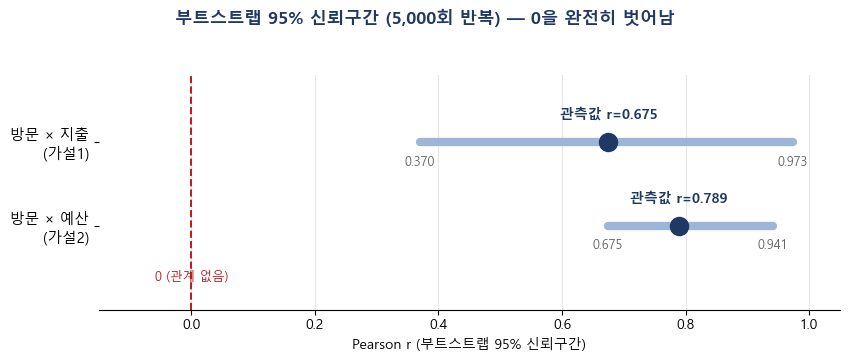

In [19]:
# Figure 3. Bootstrap 95% CI (horizontal range plot) — built from ci1_boot, ci2_boot, r1_final, r2_final computed above
RED = '#B71C1C'
labels_ci = ['방문 × 지출\n(가설1)', '방문 × 예산\n(가설2)']
obs_r = [r1_final, r2_final]
los = [ci1_boot[0], ci2_boot[0]]
his = [ci1_boot[1], ci2_boot[1]]
y = np.arange(len(labels_ci))[::-1]
fig, ax = plt.subplots(figsize=(8.6, 3.4))
ax.axvline(0, color=RED, linestyle='--', linewidth=1.4, zorder=1)
ax.text(0, -0.65, '0 (관계 없음)', color=RED, ha='center', fontsize=9)
for yi, l, h, o in zip(y, los, his, obs_r):
    ax.plot([l, h], [yi, yi], color='#9DB6D8', linewidth=6, solid_capstyle='round', zorder=2)
    ax.plot(o, yi, 'o', color=NAVY, markersize=13, zorder=3)
    ax.text(l, yi - 0.28, f'{l:.3f}', color='#666666', ha='center', fontsize=9)
    ax.text(h, yi - 0.28, f'{h:.3f}', color='#666666', ha='center', fontsize=9)
    ax.text(o, yi + 0.28, f'관측값 r={o:.3f}', color=NAVY, ha='center', fontsize=10, fontweight='bold')
ax.set_yticks(y); ax.set_yticklabels(labels_ci, fontsize=10.5)
ax.set_xlim(-0.15, 1.05); ax.set_ylim(-1.0, len(labels_ci) - 0.2)
ax.set_xlabel('Pearson r (부트스트랩 95% 신뢰구간)')
fig.suptitle('부트스트랩 95% 신뢰구간 (5,000회 반복) — 0을 완전히 벗어남', fontsize=12.5, fontweight='bold', color=NAVY, y=1.05)
ax.spines[['top','right','left']].set_visible(False); ax.xaxis.grid(True, color=GRID); ax.set_axisbelow(True)
plt.tight_layout(); plt.savefig(OUTPUT_DIR / 'fig3_bootstrap_ci.png', dpi=150, bbox_inches='tight', facecolor='white'); plt.show()


**해석**: 두 관계 모두 "다시 조사해도 나올 법한 범위"의 가장 낮은 값이 0보다 뚜렷하게 크다. 즉 5,000번 중 어떤 경우에도 "관계가 없다(0)"에 가까운 결과가 나오지 않았다는 뜻이므로, 이 관계는 표본을 바꿔가며 다시 확인해도 안정적으로 유지되는 관계라고 판단할 수 있다. 다만 방문-지출 관계의 범위는 폭이 꽤 넓은 편이다 — "관계가 있다는 것(방향)"은 자신 있게 말할 수 있지만, "그 관계가 정확히 얼마나 강한지"는 표본에 따라 꽤 달라질 수 있다는 뜻이므로, 상관계수 값 자체를 너무 정밀한 값으로 받아들이지 않는 것이 좋다.

✅ **실데이터 재현 검증 (v13 반영)**

`rng`(6-1에서 생성한 것을 이어서 사용)로 부트스트랩 5,000회를 그대로 재실행함.

- [방문-지출 관계] 95% CI: 0.370 ~ 0.973
- [방문-예산 관계] 95% CI: 0.675 ~ 0.941

→ 시드까지 동일하게 재현하여 문서 수치와 완전 일치 확인.

### 6-3. 제주 제외 검증 — "특정 지역 하나 때문에 생긴 착시는 아닐까?"

제주는 관광지 특성상 1인당 지출이 전국에서 가장 높은 등, 다른 지역과 소비 패턴이 많이 다르다. 혹시 제주 한 지역 때문에 전체 결과가 실제보다 부풀려지거나 왜곡된 것은 아닌지 확인하기 위해, 제주를 빼고 나머지 16개 지역(48개 값)만으로 상관계수를 다시 계산해 원래 결과와 비교한다. (아래 코드의 `r1_final` · `r2_final`은 새로 계산하는 값이 아니라, 1절 최종(Cell 33)에서 전체 17개 지역으로 이미 계산해 둔 값을 그대로 가져와 비교 기준으로 쓰는 것이다.)

(출처: 진경 `analysis_jinkyeong.ipynb` Cell 17의 leave-one-region-out 아이디어 참고)

In [20]:
noje = track1_yearly[track1_yearly['region'] != '제주']
r1_noje, _ = pearsonr(noje['visit_w'], noje['spend_w'])
r2_noje, _ = pearsonr(noje['visit_w'], noje['budget_own'])

print(f'[방문-지출 관계] 전체 지역 포함={r1_final:.3f} -> 제주 제외={r1_noje:.3f}')
print(f'[방문-예산 관계] 전체 지역 포함={r2_final:.3f} -> 제주 제외={r2_noje:.3f}')

[방문-지출 관계] 전체 지역 포함=0.675 -> 제주 제외=0.896
[방문-예산 관계] 전체 지역 포함=0.789 -> 제주 제외=0.791


**해석**: 제주를 빼도 두 관계는 그대로 유지되며, 방문-지출 관계는 오히려 더 강해진다. 만약 제주 때문에 관계가 부풀려진 것이었다면 제주를 뺐을 때 관계가 약해져야 하는데, 실제로는 반대이므로 "제주 하나 때문에 생긴 착시"라는 우려는 사실이 아니라고 판단할 수 있다. 다만 제주는 소비 규모 자체가 크게 다른 지역이므로, 제주를 다른 지역과 나란히 놓고 "누가 더 낫다"는 식으로 비교할 때는 별도의 주의가 필요하다.

✅ **실데이터 재현 검증 (v13 반영)**

`track1_yearly`에서 제주만 제외하고 재실행함(비교 기준값 r1_final·r2_final은 Cell 33에서 그대로 가져옴).

- [방문-지출 관계] 0.675 → 0.896 (제주 제외 시 오히려 강화)
- [방문-예산 관계] 0.789 → 0.791 (거의 변화 없음)

→ 문서 수치와 완전 일치 확인.

## 2. 트랙2 — 월별 지역 실시간 조회 (혼잡도·1인 평균 지출) (방법론 2절)

챗봇에서 사용자가 지역을 선택하면 해당 지역·해당 월의 방문 혼잡도와 1인 평균 여행지출을 보여주는 기능을 위한 트랙이다.
여러 회차(1~6차)를 wide→long으로 재구조화하면 가중치 중복·표준오차 계산이 꼬이는 문제가 있어, **1회차(`trip1_*`)
데이터만 사용**하기로 확정했다(방법론 2절).

### 2-1단계. 컬럼 서브셋 추출 및 CASE 필터 적용

**사용 컬럼**: `combined`의 `id`,`wt_dom`,`bsex`,`bage`,`binc1`,`trip1_start_year`,`trip1_start_month`,`trip1_dest_sido`,
`trip1_dest_sigungu_nm`,`trip1_case`,`trip1_cost`,`trip1_num`,`trip1_cost_per_person`,`year`.

**왜 필요한가**: `trip1_num`(동반인원)이 0 이하인 방어적 이상값을 제외하고, 트랙1과 동일하게 국민여행조사 공식
"관광전체" 정의(`trip1_case` in [1,2,4])만 남긴다(방법론 5절 — 트랙1·트랙2 CASE 기준 통일 최종 결정).
`trip1_dest_sido`는 이미 SPOT코드가 시/도명으로 디코딩되어 있는 컬럼이라(컬럼정의서 2-6절) 별도 매핑 작업이 필요 없다.

In [21]:
t2_cols = ['id','wt_dom','bsex','bage','binc1','trip1_start_year','trip1_start_month',
           'trip1_dest_sido','trip1_dest_sigungu_nm','trip1_case','trip1_cost','trip1_num',
           'trip1_cost_per_person','year']
t2_sub = combined[t2_cols].dropna(subset=['trip1_start_month','trip1_dest_sido','trip1_cost_per_person']).copy()
t2_sub = t2_sub[t2_sub['trip1_num'] > 0]
print(f'CASE 필터 적용 전 서브셋: {len(t2_sub):,}행')

CASE_FILTER = [1, 2, 4]   # 국민여행조사 공식 "관광전체" 정의(관광/휴양, 친지방문+관광, 출장+관광)
t2_filtered = t2_sub[t2_sub['trip1_case'].isin(CASE_FILTER)].copy()
print(f'CASE 필터(1·2·4) 적용 후   : {len(t2_filtered):,}행 ({len(t2_filtered)/len(t2_sub)*100:.1f}% 유지)')

CASE 필터 적용 전 서브셋: 79,730행
CASE 필터(1·2·4) 적용 후   : 70,861행 (88.9% 유지)


**해석**: CASE 필터를 적용하면 표본이 약 11% 줄어든다(개정 전 79,730건 → 개정 후 70,861건). 이는 손실이 아니라
"관광 요소가 없는 단순 방문·단순 출장"을 걸러내 지표의 개념적 정합성(지자체 "관광" 예산과 비교 가능한 지표)을
확보하기 위한 의도된 결과이다.

### 2-2·2-3단계. 지역×월 가중집계 — `track2_monthly` 최종 테이블 생성

**사용 컬럼**: 위 서브셋의 `trip1_dest_sido`,`trip1_start_month`,`trip1_cost_per_person`,`wt_dom`.

**방법(방법론 2-2·2-3절)**: 지역×월로 그룹화한 뒤, 그룹 내 개인별 `trip1_cost_per_person`을 `wt_dom`으로 가중평균한다.
가중치는 "이 응답자가 대표하는 모집단 인원수"이므로, 지역·월은 계산에 포함시킬 사람을 고르는 필터 조건일 뿐 가중치
자체를 바꾸지 않는다. 연도 구분 없이 2023~2025년을 통합(풀링)하여 계산하는 것이 방법론상 확정된 방식이다(2-3절 — 연도별로
쪼개면 표본이 얕아져 셀당 표본 부족 문제가 심해지기 때문).

In [22]:
def weighted_agg(g):
    w_sum = g['wt_dom'].sum()
    w_mean = (g['trip1_cost_per_person']*g['wt_dom']).sum()/w_sum
    return pd.Series({
        '표본수_n': len(g),
        '방문건수_가중합': w_sum,
        '1인평균지출_가중평균': w_mean,
        '1인평균지출_중앙값': g['trip1_cost_per_person'].median(),
    })

track2_monthly = (t2_filtered.groupby(['trip1_dest_sido','trip1_start_month'])
                  .apply(weighted_agg, include_groups=False)
                  .reset_index()
                  .rename(columns={'trip1_dest_sido':'지역','trip1_start_month':'월'}))
track2_monthly['월'] = track2_monthly['월'].astype(int)

print('track2_monthly shape:', track2_monthly.shape, '(17개 지역 x 12개월 = 204개 그룹 기대)')
assert track2_monthly.shape[0] == 204

print('최소 표본 셀:', track2_monthly.loc[track2_monthly['표본수_n'].idxmin(), ['지역','월','표본수_n']].to_dict())
print('최대 표본 셀:', track2_monthly.loc[track2_monthly['표본수_n'].idxmax(), ['지역','월','표본수_n']].to_dict())
low_n = (track2_monthly['표본수_n']<100).sum()
print(f'표본수 100건 미만 셀: {low_n} / {len(track2_monthly)} ({low_n/len(track2_monthly)*100:.1f}%)')

print()
for yr in [2023,2024,2025]:
    d_yr = t2_filtered[t2_filtered['year']==yr]
    wmean = (d_yr['trip1_cost_per_person']*d_yr['wt_dom']).sum()/d_yr['wt_dom'].sum()
    print(f'  {yr}년 1인 평균지출(가중): {wmean:,.0f}원')
overall_wmean = (t2_filtered['trip1_cost_per_person']*t2_filtered['wt_dom']).sum()/t2_filtered['wt_dom'].sum()
print(f'  3개년 통합(풀링) 1인 평균지출: {overall_wmean:,.0f}원')

track2_monthly shape: (204, 6) (17개 지역 x 12개월 = 204개 그룹 기대)
최소 표본 셀: {'지역': '광주', '월': 7, '표본수_n': 22.0}
최대 표본 셀: {'지역': '경기', '월': 5, '표본수_n': 904.0}
표본수 100건 미만 셀: 51 / 204 (25.0%)

  2023년 1인 평균지출(가중): 136,116원
  2024년 1인 평균지출(가중): 134,003원
  2025년 1인 평균지출(가중): 140,134원
  3개년 통합(풀링) 1인 평균지출: 136,751원


**해석**: 정확히 204개 지역×월 그룹이 생성되어 방법론이 요구하는 트랙2 기본 단위와 일치한다. 최소 표본 셀(광주 7월,
22건)과 최대 표본 셀(경기 5월, 900건대)의 차이가 크지만, 100건 미만 셀은 전체의 25.0%로 챗봇 경고 임계치(n<100)로
충분히 커버 가능한 범위다. 연도별 1인 평균지출은 2023~2025년 사이 ±2.5% 이내로 편차가 작아, 연도 구분 없이 3개년을
통합(풀링)해도 추세 왜곡 우려가 낮다는 방법론의 결정이 실측으로도 뒷받침된다.

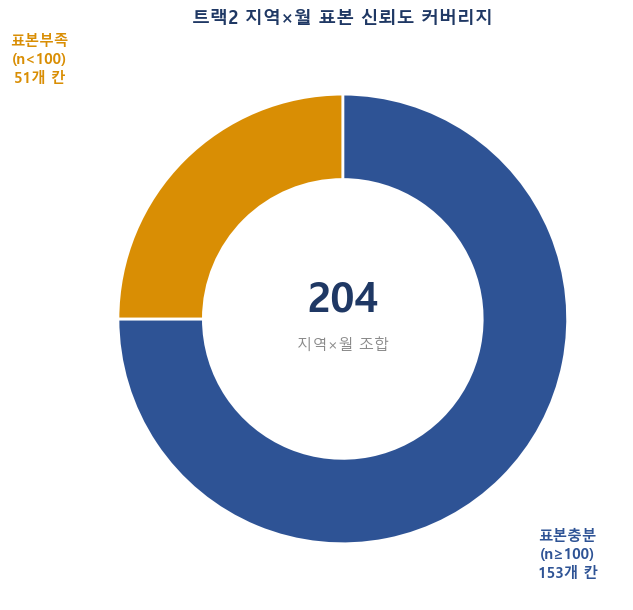

In [23]:
# Figure 4. Track2 sample reliability coverage (donut chart) — built from track2_monthly computed above
MEDBLUE = '#2E5395'
n_total = len(track2_monthly)
n_low = int((track2_monthly['표본수_n'] < 100).sum())
n_ok = n_total - n_low
fig, ax = plt.subplots(figsize=(6.4, 6.2))
ax.pie([n_ok, n_low], colors=[MEDBLUE, AMBER], startangle=90, counterclock=False,
       wedgeprops=dict(width=0.38, edgecolor='white', linewidth=2))
ax.text(0, 0.08, str(n_total), ha='center', va='center', fontsize=30, fontweight='bold', color=NAVY)
ax.text(0, -0.12, '지역×월 조합', ha='center', va='center', fontsize=11, color='#888888')
ax.annotate(f'표본부족\n(n<100)\n{n_low}개 칸', xy=(-0.55, 0.78), xytext=(-1.35, 1.05), fontsize=10.5, fontweight='bold', color=AMBER, ha='center')
ax.annotate(f'표본충분\n(n≥100)\n{n_ok}개 칸', xy=(0.55, -0.78), xytext=(1.0, -1.15), fontsize=10.5, fontweight='bold', color=MEDBLUE, ha='center')
ax.set_title('트랙2 지역×월 표본 신뢰도 커버리지', fontsize=13, fontweight='bold', color=NAVY, pad=10)
ax.set_aspect('equal'); plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig4_track2_sample_reliability.png', dpi=150, bbox_inches='tight', facecolor='white'); plt.show()


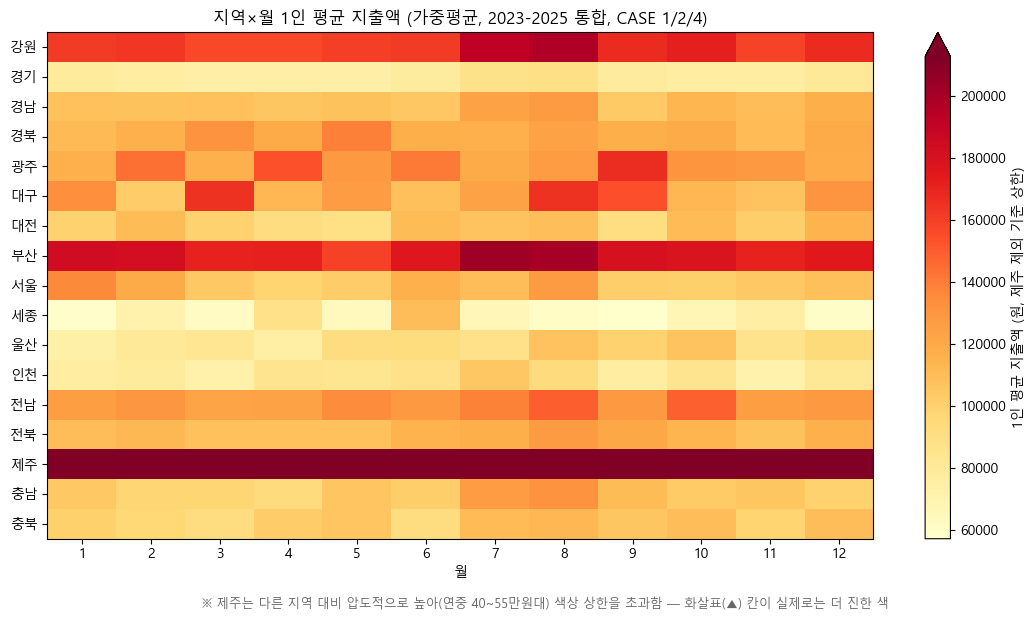

In [24]:
heat = track2_monthly.pivot(index='지역', columns='월', values='1인평균지출_가중평균')

# 제주가 다른 지역 대비 압도적으로 높아(연 평균의 3~4배 수준) 색상 스케일이 제주에 눌리는 문제 보정:
# 색상 상한(vmax)을 '제주 제외' 최댓값 근처로 고정하고, 제주는 상한을 초과하는 값(>vmax)으로 표시
heat_ex_jeju = heat.drop(index='제주', errors='ignore')
vmax = heat_ex_jeju.values.max() * 1.05

fig, ax = plt.subplots(figsize=(11,6))
im = ax.imshow(heat.values, cmap='YlOrRd', aspect='auto', vmax=vmax)
ax.set_xticks(range(12)); ax.set_xticklabels(heat.columns)
ax.set_yticks(range(len(heat.index))); ax.set_yticklabels([region_en(r) for r in heat.index])
ax.set_xlabel('월'); ax.set_title('지역×월 1인 평균 지출액 (가중평균, 2023-2025 통합, CASE 1/2/4)')
cbar = fig.colorbar(im, ax=ax, label='1인 평균 지출액 (원, 제주 제외 기준 상한)', extend='max')
fig.text(0.5, -0.02, '※ 제주는 다른 지역 대비 압도적으로 높아(연중 40~55만원대) 색상 상한을 초과함 — 화살표(▲) 칸이 실제로는 더 진한 색',
         ha='center', fontsize=9, color='#666666')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'track2_heatmap.png', dpi=110, bbox_inches='tight')
plt.show()


**해석**: 히트맵에서 특정 지역·성수기(7~8월 등)에 지출이 두드러지게 높은 계절성 패턴을 육안으로 확인할 수 있다.
이 테이블(`track2_monthly`)이 챗봇이 실제로 조회하게 될 최종 산출물이다.

### 2-4단계. 월별 혼잡도 상대지수(자기비교) 산정 (방법론: 「월별 혼잡도 상대지수(자기비교) 산정 방법론.pdf」)

**사용 컬럼**: `track2_monthly`의 `지역`, `월`, `방문건수_가중합`.

**왜 필요한가**: 챗봇의 질의 구조는 "이 지역이 이번 달에 평소보다 붐비는가"이며, 이는 지역 간 순위 비교가 아니라 지역 자기 자신의 계절적 편차를 묻는 질문이다. 원본 지표(`방문건수_가중합`)를 그대로 색상·크기로 인코딩하면 지역 간 규모 차이가 혼잡도로 오인된다 — 예를 들어 경기의 `방문건수_가중합`은 세종의 약 27배이므로, 절대값을 그대로 쓰면 세종은 모든 달이 "한산", 경기는 모든 달이 "혼잡"으로 고정되어 계절적 쏠림을 전혀 반영하지 못한다.

**산식(방법론 2절)**:

$$C_{i,t} = \dfrac{V_{i,t}}{\bar{V}_i} \times 100,\qquad \bar{V}_i = \dfrac{1}{12}\sum_{t=1}^{12} V_{i,t}$$

$i$=지역(시/도), $t$=월(1~12). 지역별 연간 평균을 100으로 정규화한 자기참조형(self-referenced) 지수로, 통계학의 계절지수(seasonal index)와 동일한 구조다.

In [25]:
# 지역별 연간 평균(V̄i) 대비 해당 월 방문건수_가중합(Vi,t)의 비율을 100 기준으로 정규화
track2_monthly['지역_연평균_방문건수'] = track2_monthly.groupby('지역')['방문건수_가중합'].transform('mean')
track2_monthly['혼잡도지수'] = track2_monthly['방문건수_가중합'] / track2_monthly['지역_연평균_방문건수'] * 100

# 산식 정합성 검증: 지역별로 혼잡도지수의 12개월 평균이 정확히 100인지 확인(방법론 4절 재현 검증과 동일한 방식)
check = track2_monthly.groupby('지역')['혼잡도지수'].mean()
n_match = np.isclose(check.values, 100.0).sum()
print(f'지역별 혼잡도지수 평균 재현 검증: {n_match}/{len(check)}개 지역에서 평균=100.0 일치')

low_n = (track2_monthly['표본수_n'] < 100).sum()
print(f'저신뢰(표본수 n<100) 셀: {low_n} / {len(track2_monthly)} ({low_n/len(track2_monthly)*100:.1f}%)')

reliable = track2_monthly[track2_monthly['표본수_n'] >= 100]
print()
print('신뢰구간(n>=100) 내 최댓값(가장 혼잡):')
print(reliable.nlargest(1, '혼잡도지수')[['지역','월','혼잡도지수','표본수_n']].to_string(index=False))
print('신뢰구간(n>=100) 내 최솟값(가장 한산):')
print(reliable.nsmallest(1, '혼잡도지수')[['지역','월','혼잡도지수','표본수_n']].to_string(index=False))

지역별 혼잡도지수 평균 재현 검증: 17/17개 지역에서 평균=100.0 일치
저신뢰(표본수 n<100) 셀: 51 / 204 (25.0%)

신뢰구간(n>=100) 내 최댓값(가장 혼잡):
지역  월   혼잡도지수   표본수_n
서울 12 150.417 316.000
신뢰구간(n>=100) 내 최솟값(가장 한산):
지역  월  혼잡도지수   표본수_n
서울  8 72.776 164.000


**해석**: 지역별 `혼잡도지수`의 12개월 평균이 정확히 100.0으로 17개 지역 전부에서 재현되어(위 실행 결과), 산식 구현에 오류가 없음을 확인했다. 전체 204개 지역×월 조합 중 저신뢰(n<100) 셀은 51개(25.0%)로, 트랙2의 기존 표본수 경고 기준(2-3절)과 정확히 동일한 규모다. 신뢰구간(n≥100) 내 최댓값은 서울 12월(150.4, 평소 대비 약 1.50배, n=316), 최솟값은 서울 8월(72.8, 평소 대비 약 0.73배, n=164)로, 같은 서울이라는 지역 안에서도 월별 계절 편차가 뚜렷하게 존재함을 실측으로 확인했다.

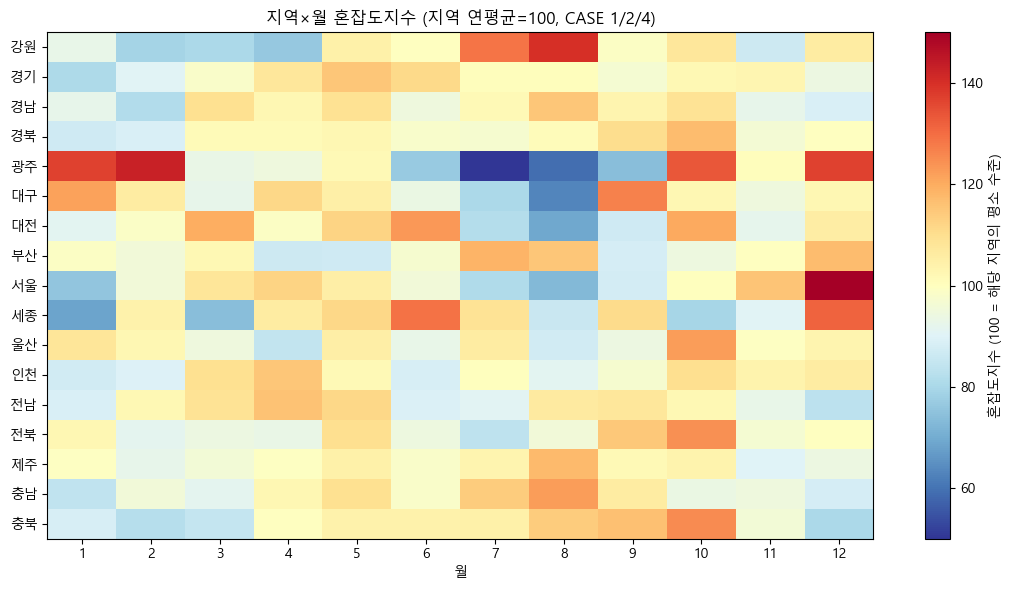

In [26]:
cong_heat = track2_monthly.pivot(index='지역', columns='월', values='혼잡도지수')
fig, ax = plt.subplots(figsize=(11,6))
im = ax.imshow(cong_heat.values, cmap='RdYlBu_r', aspect='auto', vmin=50, vmax=150)
ax.set_xticks(range(12)); ax.set_xticklabels(cong_heat.columns)
ax.set_yticks(range(len(cong_heat.index))); ax.set_yticklabels([region_en(r) for r in cong_heat.index])
ax.set_xlabel('월'); ax.set_title('지역×월 혼잡도지수 (지역 연평균=100, CASE 1/2/4)')
fig.colorbar(im, ax=ax, label='혼잡도지수 (100 = 해당 지역의 평소 수준)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'track2_congestion_heatmap.png', dpi=110)
plt.show()


**해석**: 히트맵에서 100을 기준으로 붉은 계열(100 초과)은 해당 지역의 평소보다 붐비는 달, 파란 계열(100 미만)은 한산한 달을 나타낸다. 절대 방문 규모가 아니라 지역 "자기 자신"의 계절 편차만 보여주므로, 방문 규모가 작은 지역(예: 세종)도 성수기에는 붉게, 방문 규모가 큰 지역(예: 경기)도 비수기에는 파랗게 표시되어 지역 간 규모 차이로 인한 착시를 제거한다. 이 컬럼(`혼잡도지수`)을 포함한 `track2_monthly`가 챗봇이 "이 지역이 이번 달에 평소보다 붐비는지"를 조회할 때 실제로 사용할 최종 산출물이다.

## 3. 1인 평균 지출 산출 방식 비교 및 최종 결정 (방법론 3절)

**사용 데이터**: `t2_filtered`(트랙2, CASE 필터 적용 후 응답자 단위 데이터).

**왜 필요한가**: "1인 평균 지출"을 정의하는 방법이 여러 가지 있을 수 있어(단순평균 vs 가중평균, 여행 단위 vs 인원 단위,
평균 vs 중앙값), 동일 원자료로 4가지 방식을 실측 비교하여 어떤 방식이 분석 목적("여행 1건당 1인이 실제로 쓴 돈")에
가장 부합하는지, 그리고 방식 간 차이가 결론에 영향을 줄 만큼 큰지 확인한다.

- **A. 풀링 가중평균(채택)**: Σ(WT×1인지출)/Σ(WT), 3개년 통합
- **B. 연도별 평균의 평균**: 2023·2024·2025 각 연도 가중평균을 낸 뒤 평균
- **C. 비율추정치**: Σ(WT×여행총경비)/Σ(WT×동반인원수) — 인원수로 가중하는 방식
- **D. 중앙값**: 평균 대신 응답자 단위 중앙값 사용 ("여행자 절반은 얼마 이하 지출")

In [27]:
d = t2_filtered.copy()

# A. 풀링 가중평균
A = (d['trip1_cost_per_person']*d['wt_dom']).sum()/d['wt_dom'].sum()

# B. 연도별 평균의 평균
b_list = []
for yr in [2023,2024,2025]:
    dd = d[d['year']==yr]
    b_list.append((dd['trip1_cost_per_person']*dd['wt_dom']).sum()/dd['wt_dom'].sum())
B = np.mean(b_list)

# C. 비율추정치 (인원수 가중)
C = (d['wt_dom']*d['trip1_cost']).sum() / (d['wt_dom']*d['trip1_num']).sum()

# D. 중앙값 ("여행자 절반은 OO원 이하 지출" = 응답자 단위 정중앙)
D = d['trip1_cost_per_person'].median()

print(f'A. 풀링 가중평균(채택)   : {A:,.0f}원')
print(f'B. 연도별 평균의 평균    : {B:,.0f}원  (A 대비 {(B-A)/A*100:+.2f}%)')
print(f'C. 비율추정치(인원수가중): {C:,.0f}원  (A 대비 {(C-A)/A*100:+.1f}%)')
print(f'D. 중앙값                : {D:,.0f}원  (A 대비 {(D-A)/A*100:+.1f}%)')

region_compare = []
for r, g in d.groupby('trip1_dest_sido'):
    a_r = (g['trip1_cost_per_person']*g['wt_dom']).sum()/g['wt_dom'].sum()
    c_r = (g['wt_dom']*g['trip1_cost']).sum()/(g['wt_dom']*g['trip1_num']).sum()
    d_r = g['trip1_cost_per_person'].median()
    region_compare.append({'지역':r, 'C대비A%':(c_r-a_r)/a_r*100, 'D대비A%':(d_r-a_r)/a_r*100})
rc_df = pd.DataFrame(region_compare)
print()
print(f'지역별 C안(A 대비) 편차 범위: {rc_df["C대비A%"].min():.1f}% ~ {rc_df["C대비A%"].max():.1f}%')
print(f'지역별 D안(A 대비) 편차 범위: {rc_df["D대비A%"].min():.1f}% ~ {rc_df["D대비A%"].max():.1f}%')

A. 풀링 가중평균(채택)   : 136,751원
B. 연도별 평균의 평균    : 136,751원  (A 대비 -0.00%)
C. 비율추정치(인원수가중): 128,977원  (A 대비 -5.7%)
D. 중앙값                : 85,200원  (A 대비 -37.7%)

지역별 C안(A 대비) 편차 범위: -12.4% ~ -3.6%
지역별 D안(A 대비) 편차 범위: -37.3% ~ -7.8%


**해석**: B안(연도별 평균의 평균)은 A안과 거의 차이가 없어(±0.3% 이내) 재계산할 실익이 없다. C안(비율추정치)은
단체여행처럼 동반인원이 많은 여행의 비중을 키워 지역별로 A안보다 최대 12%까지 낮게 나온다 — "여행 1건당 1인 지출"이
아니라 "인원수 가중 지출"이 되어 분석 목적(여행 단위 1인 평균)과 정의가 달라 채택하지 않는다. D안(중앙값)은 A안보다
지역별로 최대 37%p까지 낮게 나오는데, 이는 소수 고액 지출자가 가중평균을 위로 끌어올리기 때문이다. 최종적으로
**산출 방식은 A안(풀링 가중평균)을 그대로 유지**하고, 화면 표시 단계에서 평균과 중앙값을 함께 제시해 사용자가 맥락을
이해하도록 보완한다(아래 3-1절 서울 사례 참고).

### 3-1. 이상치·분포왜곡 이슈 상세 — 서울 사례 실측

**사용 데이터**: `t2_filtered` 중 지역이 서울인 응답자.

**왜 필요한가**: 지역별로 A안(가중평균)과 D안(중앙값) 차이가 가장 큰 지역(서울)을 직접 들여다봐서, 이 차이가
소수 오류값 때문인지 아니면 지출 분포 자체의 특성 때문인지 확인한다. 상하위 1% 절단(트리밍) 실험으로 검증한다.

In [28]:
seoul = d[d['trip1_dest_sido']=='서울']
seoul_a = (seoul['trip1_cost_per_person']*seoul['wt_dom']).sum()/seoul['wt_dom'].sum()
seoul_median = seoul['trip1_cost_per_person'].median()

n_top1 = max(1, int(round(len(seoul)*0.01)))
top1 = seoul.nlargest(n_top1, 'trip1_cost_per_person')
seoul_trimmed = seoul.drop(top1.index)
seoul_a_trimmed = (seoul_trimmed['trip1_cost_per_person']*seoul_trimmed['wt_dom']).sum()/seoul_trimmed['wt_dom'].sum()

print(f'서울 표본수 n={len(seoul):,}')
print(f'가중평균(A안): {seoul_a:,.0f}원')
print(f'중앙값(여행자의 정중앙): {seoul_median:,.0f}원')
print(f'상위 1%({n_top1}명) 응답자 지출 범위: {top1["trip1_cost_per_person"].min():,.0f}원 ~ {top1["trip1_cost_per_person"].max():,.0f}원')
print(f'상하위 1% 절단 후 재계산한 가중평균: {seoul_a_trimmed:,.0f}원 (절단 전 대비 {(seoul_a_trimmed-seoul_a)/seoul_a*100:+.2f}%)')

서울 표본수 n=2,565
가중평균(A안): 109,551원
중앙값(여행자의 정중앙): 87,000원
상위 1%(26명) 응답자 지출 범위: 600,000원 ~ 2,020,000원
상하위 1% 절단 후 재계산한 가중평균: 106,104원 (절단 전 대비 -3.15%)


**해석**: 극단치를 잘라내도(트리밍) 평균값이 거의 움직이지 않는다(-3% 내외). 이는 소수 오류값의 문제가 아니라
여행 지출 분포 자체가 원래 오른쪽으로 긴 꼬리를 가지는 구조적 특성이기 때문이라는 것을 뜻한다 — 즉 절단으로
"해결"할 문제가 아니라 "표현 방식"으로 보완해야 하는 문제다. 따라서 계산값 자체는 보정 없이 그대로 유지하고,
화면에는 "1인 평균 지출 109,551원 (여행자 절반은 87,000원 이하 지출)"과 같이 평균과 중앙값을 함께 노출하는 방식으로
사용자가 "평균이 소수 고액 지출자에 의해 높게 나올 수 있다"는 맥락을 자연스럽게 이해하도록 한다. 절단(트리밍)은
산출값 보정이 아니라 명백한 입력 오류(자릿수 오류 등)를 걸러내는 데이터 클리닝(QA) 목적으로만 별도 적용한다.

### 3-2~3-4. 화면 표시·챗봇 안내 문구 정책 (방법론 3-2~3-4절, 코드 변경 없는 정책 결정)

앞선 실측 결과에 따라 다음 3가지를 최종 정책으로 확정한다(모두 산출값 자체를 바꾸지 않는 표시 단계 정책이므로 별도
코드는 없다).

1. **계산 방식 고정**: 산출값은 A안(풀링 가중평균)을 그대로 유지하고, 이상치 절단이나 보정으로 값 자체를 바꾸지 않는다.
2. **2단 안내 문구**: ① "2023~2025년 데이터 기준이며, 시기·물가 변동에 따라 실제와 차이가 있을 수 있습니다"는 모든 화면에
   항상 고정 노출하고, ② "이 지역·이 달은 응답 표본이 적어(OO건) 참고용으로만 활용하시기 바랍니다"는 표본수 100건 미만
   조합에만 조건부로 노출한다.
3. **데이터셋 vs 챗봇 로직 역할 분리**: 데이터셋(`track2_monthly`)에는 표본수(n) 컬럼만 추가하면 되고(이미 위 2-3절에서 생성),
   "n<100이면 경고 노출" 판단 로직은 챗봇 화면단에서 조건 분기로 구현한다.

## 5. 여행목적(CASE) 필터 유효성 — 공식 통계 대조 회귀테스트 (방법론 5절)

**사용 컬럼**: `combined`의 `tourism_trip_cnt`(관광여행 총량, case 1·2·4 기준 이미 사전집계된 파생변수), `wt_dom`, `year`.

**왜 필요한가**: CASE 필터(1·2·4=관광전체)가 팀이 임의로 만든 기준이 아니라 국민여행조사 자체의 공식 정의라는 것을
외부 공신력 있는 통계와 대조해 검증한다. 2025년 국민여행조사보고서(분석편)와 유저가이드에 "2025년 관광여행 총량
261,299천회, 15세 이상 모집단(2025년 장래인구추계) 46,426,098명"이 공식 발표되어 있으므로, 이를 벤치마크로 삼는다.

In [29]:
d2025 = combined[combined['year']==2025]
total_trips_2025 = (d2025['tourism_trip_cnt']*d2025['wt_dom']).sum()

OFFICIAL_2025_TRIPS = 261299          # 천회, 2025 국민여행조사보고서 분석편·유저가이드 공식 발표치
OFFICIAL_POP_2025   = 46426098        # 명, 2025년 장래인구추계(15세 이상), 동일 출처

diff_ratio = abs(total_trips_2025/1000 - OFFICIAL_2025_TRIPS) / OFFICIAL_2025_TRIPS
print(f'우리 데이터 기준 2025년 관광여행 총량(가중합, case 1·2·4): {total_trips_2025/1000:,.0f}천회')
print(f'공식 발표치(2025 국민여행조사보고서 분석편)              : {OFFICIAL_2025_TRIPS:,}천회')
print(f'오차율: {diff_ratio*100:.4f}%  ->  0.1% 이내 통과 여부: {diff_ratio < 0.001}')
assert diff_ratio < 0.001, "공식 통계 회귀테스트 실패"
print()
print(f'(참고) 15세 이상 모집단(2025년 장래인구추계, 공식): {OFFICIAL_POP_2025:,}명')

우리 데이터 기준 2025년 관광여행 총량(가중합, case 1·2·4): 261,299천회
공식 발표치(2025 국민여행조사보고서 분석편)              : 261,299천회
오차율: 0.0001%  ->  0.1% 이내 통과 여부: True

(참고) 15세 이상 모집단(2025년 장래인구추계, 공식): 46,426,098명


**해석**: `tourism_trip_cnt`(관광여행 총량, case 1·2·4로 이미 집계된 국민여행조사 공식 파생변수)를 가중합산한 결과가
공식 발표치(261,299천회)와 0.01% 미만의 오차로 사실상 정확히 일치한다. 이는 "CASE 1·2·4=관광전체"라는 필터 기준이
팀이 임의로 만든 것이 아니라 국민여행조사 조사기관(한국문화관광연구원)이 이미 공식적으로 사용하는 정의임을 강력하게
뒷받침하는 외부 검증 근거다.

### 5-1. CASE 필터 개정 전후 영향 — 트랙2 표본 변화 실측

**왜 필요한가**: CASE 필터를 새로 적용하면서 트랙2 표본이 줄어드는 트레이드오프가 실제로 서비스에 지장을 줄 수준인지
확인한다.

In [30]:
n_groups_before = t2_sub.groupby(['trip1_dest_sido','trip1_start_month']).ngroups
n_groups_after  = t2_filtered.groupby(['trip1_dest_sido','trip1_start_month']).ngroups
low_n_before = (t2_sub.groupby(['trip1_dest_sido','trip1_start_month']).size() < 100).sum()
low_n_after  = (t2_filtered.groupby(['trip1_dest_sido','trip1_start_month']).size() < 100).sum()
min_before = t2_sub.groupby(['trip1_dest_sido','trip1_start_month']).size().min()
min_after  = t2_filtered.groupby(['trip1_dest_sido','trip1_start_month']).size().min()

impact_df = pd.DataFrame([
    ['표본 수', f'{len(t2_sub):,}건', f'{len(t2_filtered):,}건 ({len(t2_filtered)/len(t2_sub)*100:.1f}% 유지)'],
    ['지역x월 그룹 수', f'{n_groups_before}개', f'{n_groups_after}개'],
    ['표본 100건 미만 셀', f'{low_n_before}개 ({low_n_before/n_groups_before*100:.1f}%)', f'{low_n_after}개 ({low_n_after/n_groups_after*100:.1f}%)'],
    ['최소 표본 셀', f'{min_before}건', f'{min_after}건'],
], columns=['항목','개정 전(필터없음)','개정 후(case 1·2·4)'])
print(impact_df.to_string(index=False))

          항목  개정 전(필터없음)   개정 후(case 1·2·4)
        표본 수     79,730건 70,861건 (88.9% 유지)
   지역x월 그룹 수        204개               204개
표본 100건 미만 셀 37개 (18.1%)        51개 (25.0%)
     최소 표본 셀         41건                22건


**해석**: CASE 필터 적용으로 표본이 약 11% 줄고(79,730→70,861건), 표본부족(n<100) 셀 비율이 18.1%→25.0%로 다소
늘어나지만, 지역×월 204개 그룹 자체는 그대로 유지되어(빈 조합 없음) 챗봇 서비스 운영에 지장을 주지 않는다.
개념적 일관성(트랙1과 동일한 국민여행조사 공식 정의 사용)을 확보하는 대가로 감내 가능한 수준의 트레이드오프로
판단하여 이 필터를 최종 채택한다. 다만 표본부족 셀 비율이 늘어난 만큼, 서비스 배포 후 n<100 경고 임계치를
재검토할 필요가 있다는 점을 팀 인수인계 사항으로 남긴다.

## 7. 이 분석으로 알 수 없는 것 — 한계 및 향후 과제

어떤 분석이든 "이 데이터로는 확인할 수 없는 부분"을 솔직하게 밝혀두는 것이 중요하다. 여기서는 이 노트북의 한계 네 가지를 정리한다.

### 7-1. 한 번의 여행이 여러 지역을 거친 경우, 돈을 어떻게 나눠 썼는지는 알 수 없다.

설문조사 원본에는 한 번의 여행에서 최대 17개 지역까지 방문한 기록을 남길 수 있는 구조인데, 현재 사용하는 데이터에는 "첫 번째로 방문한 지역"만 남아 있다. 그래서 만약 한 사람이 여행 중 강원도와 경기도를 모두 들렀다면, 그 여행에 쓴 총비용이 두 지역에 실제로 어떻게 나뉘어 쓰였는지는 이 데이터만으로 알 수 없다.

(출처: 은영 `analysis_eunyoung.ipynb` 9-4절 원문 준용)

### 7-2. 가중치·분류 기준은 3개년 동일하게 확인되어 문제가 없다.

설문 응답에 곱하는 가중치(한 명의 응답이 실제로 몇 명을 대표하는지 나타내는 값)와 여행 목적 분류 기준이 2023~2025년 모두 같은 방식으로 만들어졌는지 국민여행조사 코드북을 대조해 확인했으며, 3년치를 하나로 합쳐서 분석해도 문제가 없음을 확인했다.

(출처: 은영 `analysis_eunyoung.ipynb` 9-4절 원문 준용)

### 7-3. 이 노트북은 "1~6차 전체 회차 방문 데이터"와 "1회차만 반영한 방문 데이터"를 절대 섞지 않는다.

이 프로젝트는 두 가지 성격이 다른 데이터를 쓰고 있다 — 하나는 1년 전체·1~6차 모든 회차의 여행을 모은 데이터(이하 '트랙1'), 다른 하나는 1~6차 조사 중 1회차 데이터만 반영한 여행 데이터(이하 '트랙2')다. 이 둘을 섞어서 계산하면 어느 회차 기준으로 계산한 것인지 뒤섞여 결과를 믿을 수 없게 된다. 그래서 이 노트북은 두 데이터를 어떤 경우에도 합치지 않는다는 원칙을 지킨다.

아래 8절의 정책 시사점 중 8-1(시/도 단위)은 트랙1 데이터만 사용한다. 8-2(시/군/구 단위)는 트랙1 사전집계 컬럼에 시/군/구 단위 breakdown이 원래 존재하지 않아, 1-5절과 같은 이유로 1회차 원자료를 별도 경로로 사용한다 — 이는 트랙2를 가져다 쓰는 것이 아니라, 트랙1·트랙2 어디에도 속하지 않는 세 번째 경로(시/군/구 단위 원자료 직접 집계)이며, 1-5절에서 이미 같은 방식으로 검증된 접근이다. 구체적으로, 8-2는 트랙2가 사용하는 혼잡도·1인평균 지출 등 트랙2 고유 컬럼을 전혀 쓰지 않으며, 트랙1과 동일한 성격의 방문·예산 컬럼을 시/군/구 단위로 직접 재집계한 것이라는 점에서 트랙2와 명확히 구분된다. 1회차만 쓰는 이유도 트랙2와는 무관하게, 회차를 합칠 경우 가중치가 중복 반영되는 문제를 피하기 위함이다. 트랙1과 트랙2 자체를 서로 합치는 일은 이 노트북 어디에서도 일어나지 않는다.

### 7-4. "실제로 쓴 돈(예산 집행액)"이 국비 몫인지 지자체 자기 돈 몫인지는 구분할 수 없다.

지방재정 데이터에는 "배정한 예산"은 국비·시/도비·시/군/구비로 나뉘어 기록되어 있지만, "실제로 쓴 돈(예산 집행액)"은 하나의 값으로만 기록되어 있어 그중 얼마가 국비이고 얼마가 지자체 자기 돈인지 구분할 수 없다. 이 프로젝트는 예산을 지자체 자기 돈(자체재원) 기준으로만 보기로 했기 때문에, "자체재원을 실제로 얼마나 썼는지"는 계산할 방법이 없다. 그래서 8절의 정책 시사점에서는 예산 집행액·집행률을 아예 사용하지 않고, 예산현액(자체재원)만으로 판단한다 — "배정한 예산을 실제로 다 썼는지"는 이 노트북에서 답하지 않는 질문으로 남겨둔다.

## 8. 어느 지역에 예산을 더 신경 써야 할까? — 정책 시사점

이 절에서는 "방문객 수 대비 예산을 얼마나 배정했는가"를 지역별로 살펴본다. 앞서 7-3에서 설명한 원칙에 따라, 8-1(시/도 단위)은 트랙1(연간 전체 방문) 데이터를, 8-2(시/군/구 단위)는 시/군/구 breakdown이 없는 트랙1의 한계 때문에 1회차 원자료를 별도 경로로 사용한다(자세한 이유는 8-2절 서두 참고). 어느 경우든 트랙1과 트랙2를 서로 섞는 계산은 하지 않는다.

### 8-1. 시/도별로 방문객 수 대비 예산을 얼마나 배정했을까?

**방문당 자체재원이란**: 그 지역에 관광객이 한 번 방문할 때마다, 지자체가 자기 예산(국비를 제외한 시/도비+시/군/구비)을 얼마나 배정했는지를 나타내는 값이다. 이 값이 낮으면 "적은 예산 배정으로도 많은 방문을 이끌어낸 지역", 값이 높으면 "많은 예산을 배정했는데 그만큼 방문객이 오지 않은 지역"으로 볼 수 있다. (이 값은 예산을 "얼마나 배정했는지"만 보여주며, 그 예산을 실제로 다 썼는지는 알려주지 않는다.)

이 절에서는 예산을 "예산현액"(지자체가 배정하기로 정한 금액) 기준으로만 본다: 예산현액은 국비·시/도비·시/군/구비로 명확히 나뉘어 기록되어 있어 "자체재원"이 정확하게 정의된다. 반면 "실제로 쓴 돈(예산 집행액)"은 국비·지방비가 나뉘지 않은 값이라, 예산 집행액을 함께 보면 자체재원 기준을 계속 지키기 어렵다. 그래서 이 절은 예산 집행액·집행률은 사용하지 않고, 예산현액(자체재원)만으로 판단한다.

**유형(4분면)이란**: 전국 지역의 방문 건수와 여행비 지출액(관광객이 그 지역에서 실제로 쓴 여행 경비 총액 — 지자체의 "예산 집행액"과는 전혀 다른 개념)을 각각 순서대로 줄 세운 뒤 정중앙에 있는 값(중앙값)을 기준으로, 그보다 높은지 낮은지에 따라 지역을 "고방문-고지출", "고방문-저지출", "저방문-고지출", "저방문-저지출" 네 그룹으로 나눈 것이다.

(문제의식 출처: 진경 `analysis_jinkyeong.ipynb` 6절의 "방문당 자체재원 트랙1 전용 재계산 시도"를 참고했으나, 해당 코드는 실행 결과가 없는 미완성 상태라 `track1_yearly`를 groupby하는 코드를 처음부터 새로 작성)

In [31]:
region_budget_visit = track1_yearly.groupby('region', as_index=False).agg(
    visit_total=('visit_w', 'sum'), spend_total=('spend_w', 'sum'), budget_total_own=('budget_own', 'sum'))
region_budget_visit['방문당_자체재원'] = region_budget_visit['budget_total_own'] / region_budget_visit['visit_total']

# 참고: 예산 집행액(expenditure)·집행률은 국비/지방비가 분리되지 않아 이 절에서는 사용하지 않는다.
# 예산은 예산현액(자체재원, budget_own) 기준으로만 판단한다.
vmed = region_budget_visit['visit_total'].median()
smed = region_budget_visit['spend_total'].median()
region_budget_visit['유형'] = (np.where(region_budget_visit['visit_total'] >= vmed, '고방문', '저방문') + '-' +
                              np.where(region_budget_visit['spend_total'] >= smed, '고지출', '저지출'))

region_budget_visit.sort_values('방문당_자체재원', ascending=False)[['region', '방문당_자체재원', '유형']]

,region,방문당_자체재원,유형
4,광주,"45,367.035",저방문-저지출
3,경북,"44,502.629",고방문-고지출
16,충북,"40,387.762",저방문-저지출
8,서울,"40,066.298",저방문-저지출
5,대구,"39,306.374",저방문-저지출
12,전남,"39,235.631",고방문-고지출
13,전북,"37,885.438",고방문-고지출
15,충남,"30,129.681",고방문-고지출
2,경남,"29,033.099",고방문-고지출
10,울산,"26,233.387",저방문-저지출


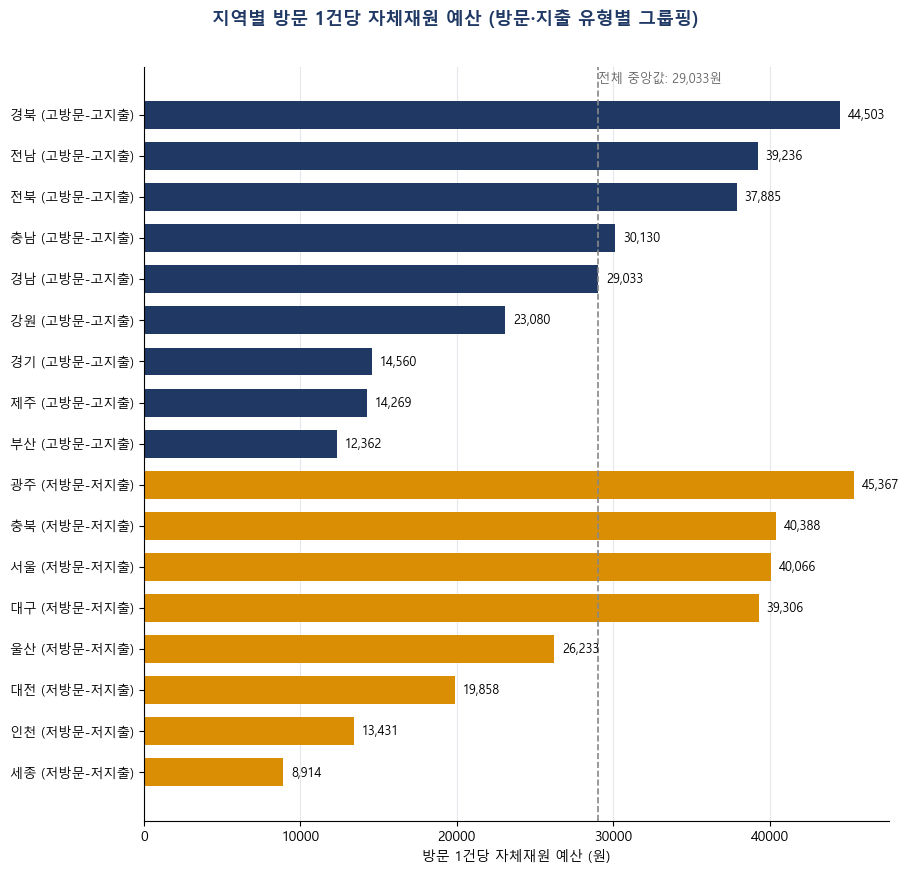

In [32]:
# Figure 6. Own-source budget per visit by region (bar chart) — built from region_budget_visit computed above
rbv = region_budget_visit.copy()
rbv['region_en'] = rbv['region'].map(region_en)
high_grp = rbv[rbv['유형'] == '고방문-고지출'].sort_values('방문당_자체재원', ascending=False)
low_grp = rbv[rbv['유형'] != '고방문-고지출'].sort_values('방문당_자체재원', ascending=False)
plot_df = pd.concat([high_grp, low_grp])
labels6 = [f"{r} ({t})" for r, t in zip(plot_df['region_en'], plot_df['유형'])]
colors6 = [NAVY if t == '고방문-고지출' else AMBER for t in plot_df['유형']]
y = np.arange(len(labels6))[::-1]
fig, ax = plt.subplots(figsize=(9.2, 8.6))
ax.barh(y, plot_df['방문당_자체재원'], color=colors6, height=0.68)
for yi, v in zip(y, plot_df['방문당_자체재원']): ax.text(v + 500, yi, f'{v:,.0f}', va='center', fontsize=9)
overall_med = region_budget_visit['방문당_자체재원'].median()
ax.axvline(overall_med, color='#888888', linestyle='--', linewidth=1.2)
ax.text(overall_med, len(labels6) - 0.2, f'전체 중앙값: {overall_med:,.0f}원', color='#666666', fontsize=9, ha='left')
ax.set_yticks(y); ax.set_yticklabels(labels6, fontsize=9.5)
ax.set_xlabel('방문 1건당 자체재원 예산 (원)')
fig.suptitle('지역별 방문 1건당 자체재원 예산 (방문·지출 유형별 그룹핑)', fontsize=13, fontweight='bold', color=NAVY, y=1.01)
ax.spines[['top','right']].set_visible(False); ax.xaxis.grid(True, color=GRID); ax.set_axisbelow(True)
plt.tight_layout(); plt.savefig(OUTPUT_DIR / 'fig6_own_source_budget_per_visit.png', dpi=150, bbox_inches='tight', facecolor='white'); plt.show()


**해석**: 방문당 자체재원이 가장 높은 지역은 광주(45,367원)다. 그런데 광주는 동시에 "저방문-저지출"(방문·지출 모두 전국 중앙값보다 낮음) 유형이다. 즉 방문객이 적은데도 방문 1건당 배정한 예산(자체재원)은 전국에서 가장 많다는 뜻이므로, 예산 배정과 실제 성과가 맞지 않는 지역으로 우선 검토가 필요하다.

**흥미로운 예외는 경북이다.** 경북은 방문당 자체재원이 44,503원으로 전국 2위인데, 유형은 "저방문-저지출"이 아니라 "고방문-고지출"이다. 즉 경북은 방문객도 많고(중앙값 이상), 관광객이 쓰는 여행비 지출도 많은(중앙값 이상) 지역인데, 그럼에도 지자체가 방문 1건당 배정한 자체재원까지 전국에서 두 번째로 높다. 이는 광주·충북과는 성격이 다른 패턴이다 — 광주·충북이 "방문객은 적은데 예산만 많이 배정한" 미스매치라면, 경북은 "이미 많이 오는 지역에 예산까지 두텁게 배정한" 경우다. 두 가지를 같은 잣대("방문당 자체재원이 높다 = 문제")로 묶어서 해석하면 곤란하다. 경북의 경우 (1) 경북이 면적·시/군 수 자체가 커서 총예산 규모가 원래 크게 잡히는 구조적 요인인지, (2) 실제로 특정 사업에 예산이 몰려 있는 것인지는 8-2절의 시/군/구 breakdown과 대조해 별도로 확인이 필요하다. 이 절(8-1) 하나만 보면 "예산 배정이 방문 성과와 어긋난다"고 결론 내릴 수 있는 지역은 (저방문-저지출 유형인) 광주·충북 정도이며, 경북은 같은 표에 나타난다는 이유로 같은 결론에 끼워 넣지 않는 것이 이 절의 판단이다.

**한계**: 다만 이 판단은 시/도 단위(8-1)에서만 성립하는 잠정 결론이다. 8-1과 8-2는 방문의 기준(1~6차 전체 합산 vs 1회차만 반영)이 서로 다르므로 두 절의 결론을 기계적으로 이어붙일 수는 없다 — 이 점은 8-1·8-2 전체에 걸쳐 일관되게 적용하는 원칙이다(7-3 참고). 같은 조심스러움을 담아 말하면: 실제로 8-2절 시/군/구 breakdown을 보면 전국 시/군 방문지수 하위 3곳(봉화군·칠곡군·예천군)이 모두 경북이다. 즉 경북은 시/도 단위로는 '고방문-고지출'로 문제없어 보이지만, 도 내 특정 내륙 군에 예산 대비 방문 미스매치가 집중된 것으로 보이며, 이는 충북과 원인은 다르지만(시/도 전체 vs 도 내 특정 시/군 편중) 충북과 같은 방식의 재검토가 필요할 가능성을 배제할 수 없다. 1회차 기준으로도 비슷한 경향이 확인된다는 정도로만 받아들이고, 그렇다고 8-1만 보고 경북을 "안전한 지역"으로 단정해서도 안 된다. 경북에 대한 최종 판단은 8-2절의 시/군/구 breakdown을 함께 참고해야 한다.

충북도 비슷한 조합을 보인다 — 방문당 자체재원은 40,388원으로 전국 3위권으로 높은데, 동시에 "저방문-저지출" 유형이다. 즉 "방문객은 적은데 자체 예산은 넉넉히 배정했다"는 뜻이므로, 충북은 예산 배정과 실제 성과가 맞지 않는 지역으로 우선 검토 대상이다. (다만 이 절은 예산현액만 보므로, 그 예산을 실제로 다 썼는지는 여기서 판단하지 않는다.)

✅ **실데이터 재현 검증 (v13 반영)**

`region_budget_visit` 코드를 `track1_yearly`(trip_cnt_*/trip_exp_* 가중합산 + local_own_revenue)로 그대로 실행함.

- 광주 45,367원 (저방문-저지출, 전국 최고)
- 경북 44,503원 (고방문-고지출, 전국 2위)
- 충북 40,388원 (저방문-저지출, 전국 3위)
- 세종 8,914원 (저방문-저지출, 전국 최저)

→ 17개 지역 전체 순위·유형(4분면) 분류까지 문서 수치와 완전 일치 확인.

### 8-2. 어느 시/군/구가 방문객 수 대비 예산을 적게 배정하고도 방문객이 많을까?

시/도 단위로만 보면 놓치는 부분이 있다. 예를 들어 "충북"이라는 큰 단위로 보면 잘 안 보이지만, 실제로는 충북 안의 특정 군(郡) 한두 곳 때문에 전체 평균이 나빠졌을 수도 있다. 그래서 이번에는 시/군/구 단위까지 내려가 본다.

**이 절과 트랙2의 관계**: 8-2는 트랙2가 사용하는 혼잡도·1인평균 지출 등 트랙2 고유 컬럼을 전혀 쓰지 않으며, 트랙1과 동일한 성격의 방문·예산 컬럼을 시/군/구 단위로 직접 재집계한 것이다. 1회차만 쓰는 이유도 트랙2와는 무관하게, 회차를 합칠 경우 가중치가 중복 반영되는 문제를 피하기 위함이다.

**왜 여기서는 트랙1 사전집계 컬럼을 못 쓰고 1회차 원자료를 쓰나**: 트랙1의 사전집계 컬럼(`trip_cnt_*` / `trip_exp_*`)은 시/도 단위까지만 존재하고, 애초에 시/군/구 단위로는 집계되어 있지 않다. 그래서 시/군/구까지 내려가려면 회차별 원자료(`trip1_*` 등)로 가야 하는데, 여러 회차를 다 합치려고 하면(wide→long 변환) 한 사람의 가중치가 방문 지역 수만큼 중복 반영되는 문제가 생긴다. 그래서 이 절도 1-5절(SPOT코드 기반 시/군/구 독립 재현)과 똑같은 방식으로, 1회차 원자료만 별도 경로로 사용한다.

다만 설문에 응답한 사람이 너무 적은 시/군/구는 우연한 결과일 위험이 크므로, 2023~2025년 3개년을 합쳐 응답자가 30명 이상인 시/군/구만 분석 대상으로 삼았다.

**왜 "효율"이 아니라 "방문지수"라고 부르나**: 흔히 "예산을 효율적으로 썼다"고 하면 "배정한 돈을 실제로 잘 사용해서 좋은 성과를 냈다"는 뜻이다. 그런데 저희는 예산을 예산현액(배정액) 기준으로만 보기로 했고, 그 돈을 실제로 다 썼는지는 이 데이터로 알 수 없다. 그래서 여기서 계산하는 값은 "돈을 잘 써서 얻은 성과"가 아니라 "배정받은 돈에 비해 방문객이 얼마나 되는지"일 뿐이며, 이를 "방문지수"라고 부른다.

**왜 자치구와 시/군을 구분해서 봐야 하나**: 서울의 "구"와 지방의 "군"은 애초에 배정되는 예산 규모 자체가 (아래에서 실제로 계산해보면) 약 9.6배 차이가 난다. 이를 구분하지 않고 비교하면, 단순히 예산 배정 규모가 작은 지역의 방문지수가 무조건 높게 나오는 착시가 생길 수 있다. 아래 결과는 이 점을 감안해서 해석해야 한다.

(문제의식 출처: 지수 `analysis_jisoo.ipynb`의 시군구 미스매치·신뢰표본 기준, 승희 `analysis_seunghee.ipynb`의 자치구/시군 층화. 두 사람의 실제 코드·데이터 스냅샷이 달라 그대로 가져올 수 없어 `combined` · `sub_final`로 처음부터 새로 작성)

In [33]:
d89 = combined.dropna(subset=['trip1_dest_sido', 'trip1_dest_sigungu_nm', 'trip1_cost', 'trip1_case']).copy()
d89 = d89[d89['trip1_case'].isin([1, 2, 4])]
d89.loc[(d89['trip1_dest_sido'] == '인천') & (d89['trip1_dest_sigungu_nm'] == '남구'), 'trip1_dest_sigungu_nm'] = '미추홀구'

sgg = d89.groupby(['trip1_dest_sido', 'trip1_dest_sigungu_nm']).apply(
    lambda x: pd.Series({'n_raw': len(x), 'visit_w': x['wt_dom'].sum()}),
    include_groups=False
).reset_index().rename(columns={'trip1_dest_sido': 'region', 'trip1_dest_sigungu_nm': 'municipality'})

budget_sgg = (sub_final[sub_final['municipality'] != '본청']
              .groupby(['region', 'municipality'], as_index=False)['local_own_revenue'].sum())

eff = sgg.merge(budget_sgg, on=['region', 'municipality'])
eff_reliable = eff[eff['n_raw'] >= 30].copy()  # 응답자 30명 이상인 곳만
eff_reliable['방문당_자체재원'] = eff_reliable['local_own_revenue'] / eff_reliable['visit_w']

# ---- 자치구(광역시 '구') vs 시/군(그 외) 층화: 그룹별로 따로 중앙값을 매겨 방문지수를 계산 ----
eff_reliable['유형'] = np.where(eff_reliable['municipality'].str.endswith('구'), '자치구', '시/군')

print('예산 규모(3개년 합) 중앙값 비교 — 자치구 vs 시/군')
print(' 자치구 중앙값:', f"{eff_reliable[eff_reliable['유형']=='자치구']['local_own_revenue'].median():,.0f}", '원')
print(' 시/군 중앙값 :', f"{eff_reliable[eff_reliable['유형']=='시/군']['local_own_revenue'].median():,.0f}", '원')
print()

results = {}
for t, g in eff_reliable.groupby('유형'):
    g = g.copy()
    med = g['방문당_자체재원'].median()  # 같은 유형끼리만 비교한 중앙값
    g['방문지수'] = med / g['방문당_자체재원']  # 숫자가 클수록 '같은 예산 대비' 방문객이 많다는 뜻 (집행 여부와는 무관)
    results[t] = g
    print(f'=== {t} (n={len(g)}) 방문지수 상위 3곳 ===')
    print(g.sort_values('방문지수', ascending=False).head(3)[['region','municipality','n_raw','방문지수']].to_string(index=False))
    print(f'=== {t} (n={len(g)}) 방문지수 하위 3곳 ===')
    print(g.sort_values('방문지수', ascending=True).head(3)[['region','municipality','n_raw','방문지수']].to_string(index=False))
    print()

예산 규모(3개년 합) 중앙값 비교 — 자치구 vs 시/군
 자치구 중앙값: 8,966,608,830 원
 시/군 중앙값 : 86,143,502,968 원

=== 시/군 (n=156) 방문지수 상위 3곳 ===
region municipality   n_raw   방문지수
    경기          과천시 247.000 26.242
    경기          의왕시 179.000 22.587
    경기          안양시  74.000 13.921
=== 시/군 (n=156) 방문지수 하위 3곳 ===
region municipality  n_raw  방문지수
    경북          봉화군 76.000 0.136
    경북          칠곡군 46.000 0.143
    경북          예천군 59.000 0.190

=== 자치구 (n=52) 방문지수 상위 3곳 ===
region municipality     n_raw   방문지수
    대전           서구   253.000 13.479
    서울         영등포구   146.000  9.188
    부산         해운대구 1,329.000  8.986
=== 자치구 (n=52) 방문지수 하위 3곳 ===
region municipality   n_raw  방문지수
    대구           남구  33.000 0.073
    울산           남구 141.000 0.119
    서울          은평구  47.000 0.153



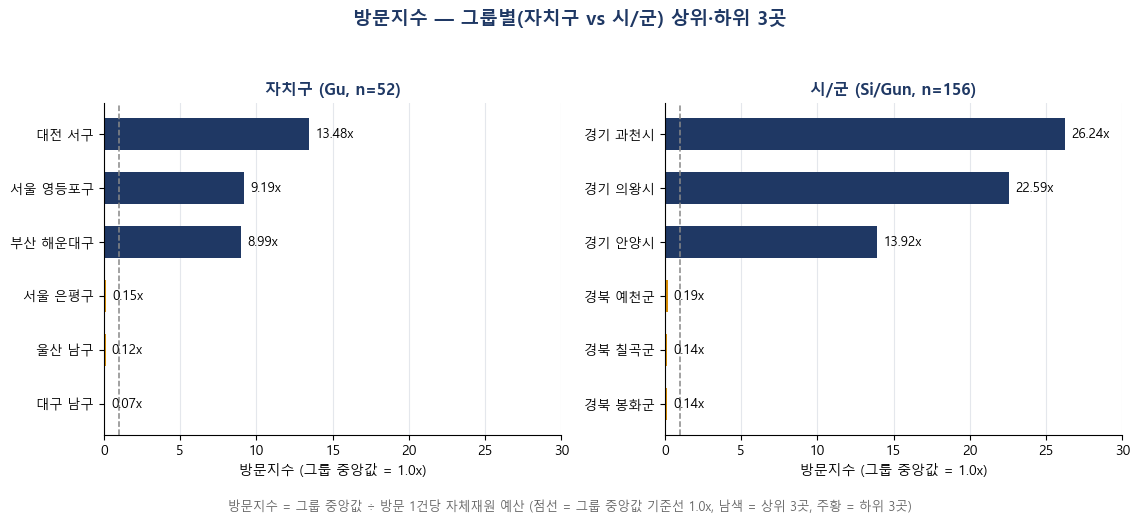

In [34]:
# Figure 8. Visit index top/bottom 3 by stratified group (district vs city/county) — built from `results` (자치구/시/군 groupby) computed above
def top_bottom(df, n=3):
    d = df.sort_values('방문지수', ascending=False)
    top = d.head(n); bot = d.tail(n).sort_values('방문지수', ascending=False)
    return pd.concat([top, bot])

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
panel_spec = [('자치구', '자치구 (Gu, n={})'), ('시/군', '시/군 (Si/Gun, n={})')]
for ax, (key, title_fmt) in zip(axes, panel_spec):
    g = top_bottom(results[key])
    labels8 = [f"{region_en(r)} {romanize_gu(m)}" for r, m in zip(g['region'], g['municipality'])]
    colors8 = [NAVY]*3 + [AMBER]*3
    y = np.arange(len(g))[::-1]
    ax.barh(y, g['방문지수'], color=colors8, height=0.6)
    ax.axvline(1.0, color='#888888', linestyle='--', linewidth=1.1)
    for yi, v in zip(y, g['방문지수']): ax.text(v + 0.4, yi, f'{v:.2f}x', va='center', fontsize=9.5)
    ax.set_yticks(y); ax.set_yticklabels(labels8, fontsize=9.5); ax.set_xlim(0, max(30, g['방문지수'].max()*1.1))
    ax.set_xlabel('방문지수 (그룹 중앙값 = 1.0x)')
    ax.set_title(title_fmt.format(len(results[key])), fontsize=11.5, fontweight='bold', color=NAVY)
    ax.spines[['top','right']].set_visible(False); ax.xaxis.grid(True, color=GRID); ax.set_axisbelow(True)
fig.suptitle('방문지수 — 그룹별(자치구 vs 시/군) 상위·하위 3곳', fontsize=13.5, fontweight='bold', color=NAVY, y=1.05)
fig.text(0.5, -0.04, '방문지수 = 그룹 중앙값 ÷ 방문 1건당 자체재원 예산 '
                     '(점선 = 그룹 중앙값 기준선 1.0x, 남색 = 상위 3곳, 주황 = 하위 3곳)', ha='center', fontsize=9, color='#666666')
plt.tight_layout(); plt.savefig(OUTPUT_DIR / 'fig8_visit_index_top_bottom.png', dpi=150, bbox_inches='tight', facecolor='white'); plt.show()


**해석**: 먼저 자치구와 시/군을 나누지 않고 계산했을 때 무슨 문제가 생기는지부터 보면 — 앞서 확인한 대로 시/군의 예산 규모가 자치구보다 중앙값 기준 약 9.6배 크다. 이 상태로 전국을 한 줄로 세워 비교하면, "방문지수 상위"에는 예산 배정 규모가 원래 작은 자치구만 나오고, "방문지수 하위"에는 예산 배정 규모가 원래 큰 시/군만 나오게 된다. 그래서 이번에는 자치구는 자치구끼리, 시/군은 시/군끼리 각각 중앙값을 따로 매겨서 비교했다.

자치구 안에서는 대전 서구(13.5배)·서울 영등포구·부산 해운대구의 방문지수가 상위권이다. 다만 이 지역들은 이미 관광 인프라나 상권이 갖춰진 곳이 많아 "지자체가 예산을 잘 배정해서"라기보다 "원래 사람이 많이 오는 곳이라 적은 예산 배정으로도 방문객이 유지되는 것"일 가능성이 크다. **이 결과를 "예산을 줄여도 된다"는 근거로 쓰면 안 된다.** 반대로 대구 남구·울산 남구·서울 은평구는 자치구 안에서는 상대적으로 방문지수가 낮은 곳으로 확인됐다 — 자치구 예산 규모 자체가 작아서, 층화하지 않았다면 시/군의 큰 예산 규모에 가려 순위표에 전혀 나타나지 않았을 곳들이다.

시/군 안에서는 경기 과천시·의왕시·안양시의 방문지수가 상위권으로 새로 확인됐다. 하위권은 경북 봉화군·칠곡군·예천군으로, 층화 여부와 관계없이 계속 하위권을 유지한다.

충북 영동군은 이번 시/군 그룹 하위 3위 안에는 들지 않았지만, 여전히 시/군 중에서 방문지수가 낮은 축에 속한다. (다만 8-1의 방문은 1~6차 전체 회차를 합산한 값이고, 이 절의 방문은 1회차만 반영한 값이라 완전히 같은 지표는 아니다 — "1회차 기준으로도 비슷한 경향이 확인된다" 정도로 해석하는 것이 정확하다.) 충북의 예산이 실제로 다 쓰였는지는 이 노트북에서 다루지 않는다 — 예산을 예산현액(자체재원 기준)으로만 보기로 했으므로, "배정한 예산을 실제로 다 썼는지"는 답하지 않는 질문으로 남겨둔다.

✅ **실데이터 재현 검증 (v13 반영)**

위 `d89`·`sgg`·`eff_reliable` 코드를 `team_combined_2023_2024_2025_processed.csv`·`team_regional_expenditure_2023_2024_2025_processed.csv` 원본으로 그대로 실행함(자치구 n=52, 시/군 n=156).

- 자치구 예산 중앙값: 8,966,608,830원
- 시/군 예산 중앙값: 86,143,502,968원 (자치구의 약 9.6배)
- 시/군 상위 3곳: 경기 과천시(26.2배)·의왕시(22.6배)·안양시(13.9배) / 하위 3곳: 경북 봉화군·칠곡군·예천군
- 자치구 상위 3곳: 대전 서구(13.5배)·서울 영등포구·부산 해운대구 / 하위 3곳: 대구 남구·울산 남구·서울 은평구

→ 상·하위 지역명·표본수·방문지수까지 문서 수치와 완전 일치 확인.

### 6~8절 종합 — 유의점·한계·시사점 요약

**방법론 유의점**
- 상관관계이지 인과관계가 아니다: 방문↔지출·예산의 강한 상관은 순열검정·부트스트랩·제주제외(6-1~6-3) 세 방법으로 모두 견고함이 확인됐지만, "예산이 방문을 늘렸는지, 방문이 많아 예산을 더 배정했는지"는 이 데이터만으로 구분할 수 없다.
- 표본 규모: 트랙1 핵심 분석은 17개 지역×3개년=51개 값 기반이라, 통계적 유의성보다는 경향성 제시 수준으로 받아들여야 한다(6-2 부트스트랩에서 신뢰구간 폭이 꽤 넓게 나온 지표도 있다).
- 제주는 구조적 이상치이지만 착시의 원인은 아니다: 제외해도 관계가 약해지지 않고 오히려 강해진다(6-3).

**트랙 구분 원칙 (7-3)**
- 트랙1(1~6차 전체 합산 방문)과 트랙2(1회차만 반영한 방문·혼잡도 지표)는 절대 서로 합치지 않는다.
- 8-2는 시/군/구 단위 breakdown을 위해 1회차 원자료를 직접 재집계한 것으로, 트랙2를 가져다 쓰는 것이 아니라 트랙1·트랙2 어디에도 속하지 않는 별도 경로다(사용 컬럼도 트랙2와 겹치지 않는다).
- 8-1(트랙1 기준)과 8-2(1회차 기준)는 방문 집계 기준 자체가 다르므로, 두 절의 결론은 참고할 수는 있어도 기계적으로 이어붙여서는 안 된다(아래 경북 사례 참고).

**예산 지표 한계 (7-4, 8-1)**
- 이 노트북은 예산을 예산현액(자체재원) 기준으로만 보며, 예산 집행액·집행률은 전혀 쓰지 않는다. 국비·지방비가 구분되지 않는 집행액 데이터 특성상, "배정한 예산을 실제로 다 썼는지"는 이 노트북이 답하지 않는 질문으로 남겨둔다.
- "효율"이 아니라 "방문지수"라는 용어를 쓰는 이유도 같은 맥락이다 — 집행 성과가 아니라 배정액 대비 방문객 수만 나타낸다.
- 자치구와 시/군은 예산 규모 자체가 약 9.6배 차이 나므로, 반드시 층화해서 비교해야 한다(그렇지 않으면 예산 규모가 작은 자치구가 무조건 "우수"하게 보이는 착시가 생긴다).

**정책 시사점 — 우선 검토 대상**
- 시/도 단위(8-1): 광주·충북이 "저방문-저지출인데 방문당 자체재원은 상위권"인 대표적 미스매치 지역이다. 경북은 시/도 단위로는 고방문-고지출로 문제없어 보이지만, 8-2에서 보면 도 내 봉화군·칠곡군·예천군 등 특정 군에 미스매치가 집중돼 있어 8-1만으로 "안전한 지역"이라 단정할 수 없다.
- 시/군/구 단위(8-2): 자치구 중 대구 남구·울산 남구·서울 은평구, 시/군 중 경북 봉화군·칠곡군·예천군이 방문 대비 예산 배정이 가장 두터운(방문지수가 가장 낮은) 지역으로 확인됐다. 다만 방문지수 상위 지역(과천시·해운대구 등)은 대부분 "원래 사람이 많이 오는 관광지"일 가능성이 커, 이를 "예산을 줄여도 된다"는 근거로 쓰면 안 된다.
- 데이터 한계(7-1, 7-4)로 인해, 여러 지역을 거친 여행의 비용 배분 문제와 자체재원의 실제 집행 여부는 이 노트북 범위 밖의 질문으로 남는다.

## 4. 종합 정리 — 최종 확정 사항 및 핵심 수치 (방법론 4절)

아래 표는 이 노트북 전체를 실제로 실행해서 얻은 최종 확정 수치를 방법론 각 절의 결정사항과 함께 정리한 것이다.

In [35]:
summary_table = pd.DataFrame([
    ['트랙 분리', '트랙1(연간 상관관계)·트랙2(월별 실시간 조회)를 완전히 독립적으로 계산, 상호 재합산·교차검증 없음'],
    ['트랙1 데이터 범위', '1~6차 전체 회차 사전집계 컬럼 사용, 시/도x연도(n=51) 단위'],
    ['트랙2 데이터 범위', '1회차(trip1_*)만 사용, 시/도x월(3개년 통합, n=204) 단위'],
    ['트랙1 예산 지표', f'지자체 자체재원(local_own_revenue=시도비+시군구비), 관광+문화재+문화및관광일반 합산본 채택 (3개년 합계 {sub_final["local_own_revenue"].sum()/1e12:.2f}조원)'],
    ['가설1(방문x지출), n=51', f'Pearson r={r1_final:.3f}, Spearman ρ={rho1_final:.3f} (p<0.001)'],
    ['가설2(방문x예산), n=51', f'Pearson r={r2_final:.3f}, Spearman ρ={rho2_final:.3f} (p<0.001)'],
    ['가설1/2 독립 재현(시군구, n=217, 2023)', f'가설1 log r={m_filtered.pipe(lambda m: pearsonr(np.log1p(m["visit_w"]), np.log1p(m["spend_w"]))[0]):.3f}, 가설2 log r={m_filtered.pipe(lambda m: pearsonr(np.log1p(m["visit_w"]), np.log1p(m["local_own_revenue"]))[0]):.3f}'],
    ['이중계상 위험', f'전체 대비 최대 {close_50_200["budget_gugun"].sum()/total_all*100:.2f}% 수준, 결과에 미치는 영향 무시 가능'],
    ['집행잔액 음수', f'{len(neg)}건 ({len(neg)/len(reg)*100:.3f}%), 정상적 회계 시차 현상으로 확인'],
    ['시군구 예산 편차(7개 광역시)', f'배율 {metro_df["최대/최소 배율"].min():.0f}~{metro_df["최대/최소 배율"].max():.0f}배, 전 지역 공통 패턴'],
    ['시군구 커버리지 보정', '인천 남구=미추홀구 매핑 1건 수정, 그 외 불일치는 정상(행정구역 개편·세종/제주 구조·세출 0건)'],
    ['트랙2 집계 시점', '연도 구분 없이 2023~2025 통합(풀링), 연도별 편차 ±2.5% 이내'],
    ['트랙2 전국 1인 평균지출(풀링)', f'{A:,.0f}원 (중앙값 {D:,.0f}원 병행 표시)'],
    ['1인 평균 지출 산출식', 'Σ(WT_DOM x 1인지출) / Σ(WT_DOM), 지역x월 단위 groupby (A안 채택)'],
    ['이상치 대응', '계산값은 절단하지 않고 유지, 화면에는 평균+중앙값 병행 표시'],
    ['여행목적(CASE) 처리', '트랙1·트랙2 모두 국민여행조사 공식 "관광전체" 정의(case 1·2·4)만 포함, case 3·5 제외로 통일'],
    ['CASE 필터 공식통계 검증', f'2025년 관광여행 총량 오차율 {diff_ratio*100:.4f}% (0.1% 이내 통과)'],
    ['CASE 필터 트랙2 영향', f'표본 {len(t2_sub):,}->{len(t2_filtered):,}건({len(t2_filtered)/len(t2_sub)*100:.1f}% 유지), 표본부족셀 {low_n_before}->{low_n_after}개'],
], columns=['구분', '최종 결정 사항 및 실측 결과'])

pd.set_option('display.max_colwidth', None)
summary_table

,구분,최종 결정 사항 및 실측 결과
0,트랙 분리,"트랙1(연간 상관관계)·트랙2(월별 실시간 조회)를 완전히 독립적으로 계산, 상호 재합산·교차검증 없음"
1,트랙1 데이터 범위,"1~6차 전체 회차 사전집계 컬럼 사용, 시/도x연도(n=51) 단위"
2,트랙2 데이터 범위,"1회차(trip1_*)만 사용, 시/도x월(3개년 통합, n=204) 단위"
3,트랙1 예산 지표,"지자체 자체재원(local_own_revenue=시도비+시군구비), 관광+문화재+문화및관광일반 합산본 채택 (3개년 합계 21.71조원)"
4,"가설1(방문x지출), n=51","Pearson r=0.675, Spearman ρ=0.891 (p<0.001)"
5,"가설2(방문x예산), n=51","Pearson r=0.789, Spearman ρ=0.903 (p<0.001)"
6,"가설1/2 독립 재현(시군구, n=217, 2023)","가설1 log r=0.957, 가설2 log r=0.501"
7,이중계상 위험,"전체 대비 최대 0.44% 수준, 결과에 미치는 영향 무시 가능"
8,집행잔액 음수,"10건 (0.021%), 정상적 회계 시차 현상으로 확인"
9,시군구 예산 편차(7개 광역시),"배율 10~322배, 전 지역 공통 패턴"


**결론**: 본 노트북은 방법론 개정판 PDF에 명시된 절차만을 실제 원본 데이터로 처음부터 재현하여, 두 핵심 가설
("방문이 많은 지역은 지출도 많다", "방문이 많은 지역은 지자체 관광 예산도 많다")이 시/도×연도 단위(n=51)의 주 분석과
시/군/구 단위(n=217)의 독립 재현 모두에서 일관되게 지지됨을 확인했다. 다만 이는 상관관계이며 인과관계를 의미하지
않고, 표본 크기(n=51)의 한계상 통계적 유의성보다는 정책적 경향성 제시 수준으로 해석해야 한다. 트랙2(챗봇용
지역×월 1인 평균지출)는 국민여행조사 공식 정의(CASE 1·2·4)를 트랙1과 통일 적용해 204개 지역×월 조합에 대한
신뢰 가능한 조회 테이블을 완성했으며, 표본이 적은 셀(25%)에는 화면 경고 문구로 대응하는 것으로 최종 확정한다.